In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import ast
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("results/result_sample_shorts_all_for_video_agent_fixed.csv")
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(df.shape)


(200, 75)


# 1. 시각화 기본 설정

In [3]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 보기 편한 스타일
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 분석 컬럼 정의
numeric_cols = [
    "avg_brightness",
    "avg_blue",
    "avg_green",
    "avg_red",
    "person_ratio",
    "face_ratio",
    "text_ratio",
]

categorical_cols = [
    "production_quality",
    "lighting_style",
    "color_mood",
    "editing_pace",
    "motion_graphic",
    "video_format",
    "first_3sec",
    "background_style",
]

numeric_cols = [col for col in numeric_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

print("수치형 컬럼:", numeric_cols)
print("범주형 컬럼:", categorical_cols)

수치형 컬럼: ['avg_brightness', 'avg_blue', 'avg_green', 'avg_red', 'person_ratio', 'face_ratio', 'text_ratio']
범주형 컬럼: ['production_quality', 'lighting_style', 'color_mood', 'editing_pace', 'motion_graphic', 'video_format', 'first_3sec', 'background_style']


# 2. 그룹별 샘플 수 시각화

,domain,success_label,count
0,FnB,fail,52
1,FnB,success,48
2,IT,fail,58
3,IT,success,42


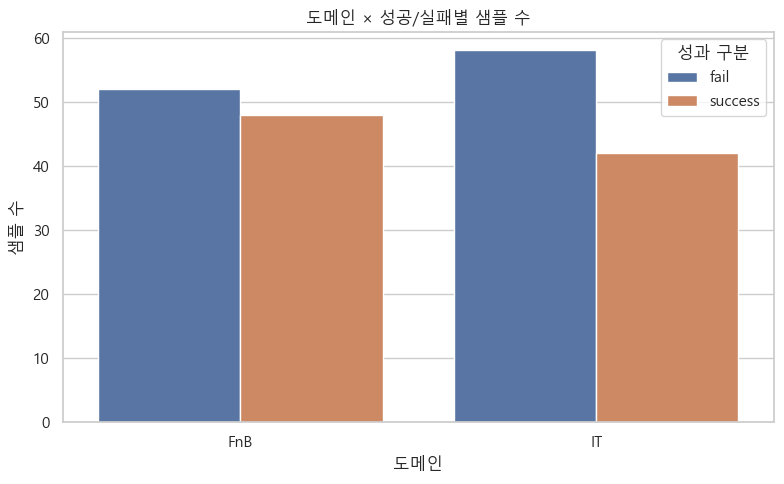

In [4]:
group_count = (
    df.groupby(["domain", "success_label"])
      .size()
      .reset_index(name="count")
)

display(group_count)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=group_count,
    x="domain",
    y="count",
    hue="success_label"
)
plt.title("도메인 × 성공/실패별 샘플 수")
plt.xlabel("도메인")
plt.ylabel("샘플 수")
plt.legend(title="성과 구분")
plt.tight_layout()
plt.show()

# 3. 수치형 변수 전체 분포 확인

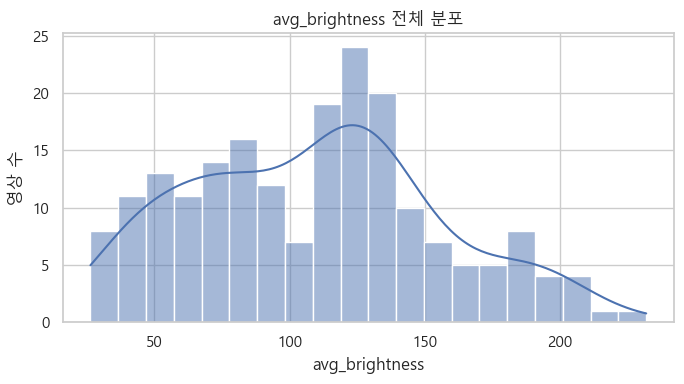

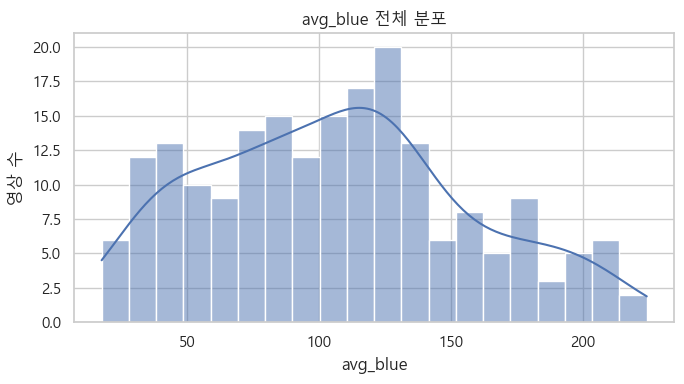

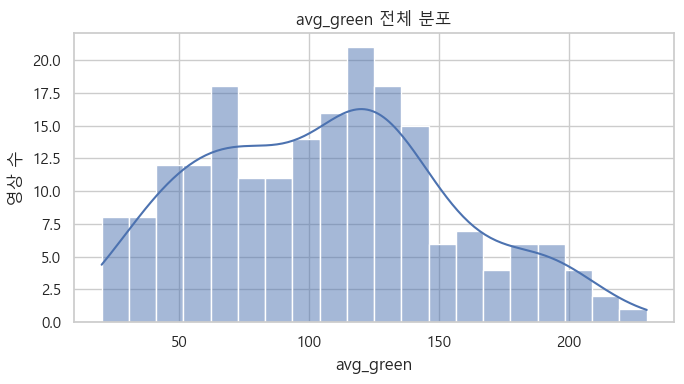

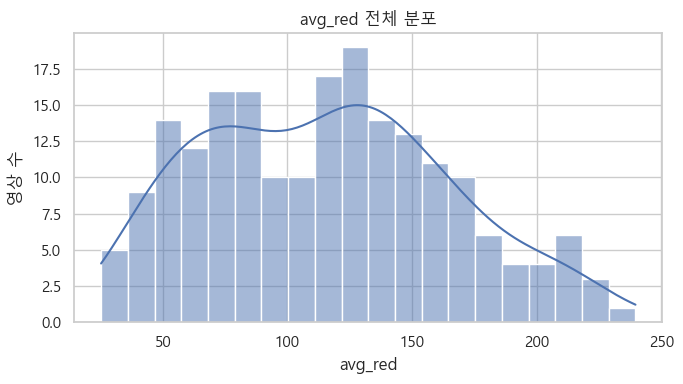

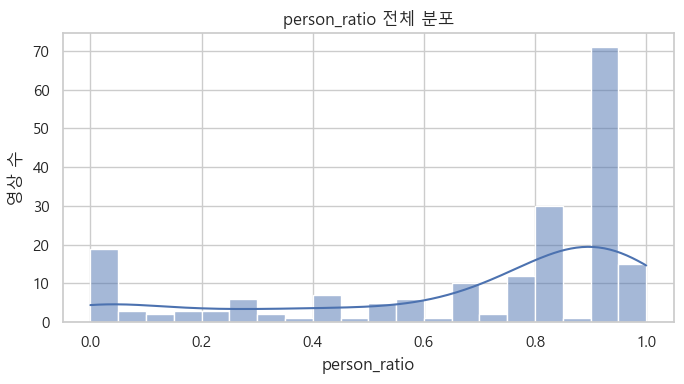

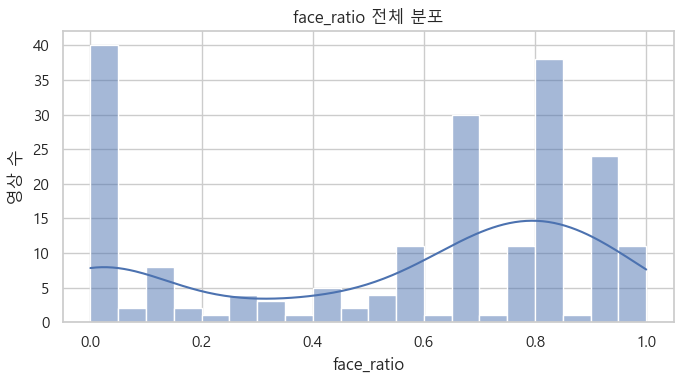

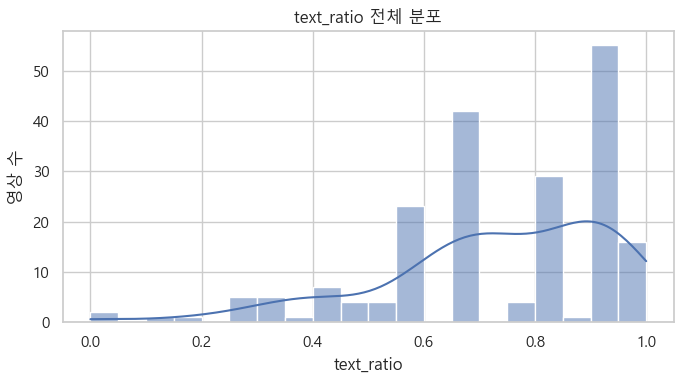

In [5]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )
    plt.title(f"{col} 전체 분포")
    plt.xlabel(col)
    plt.ylabel("영상 수")
    plt.tight_layout()
    plt.show()

# 4. 성공/실패별 수치형 분포 비교

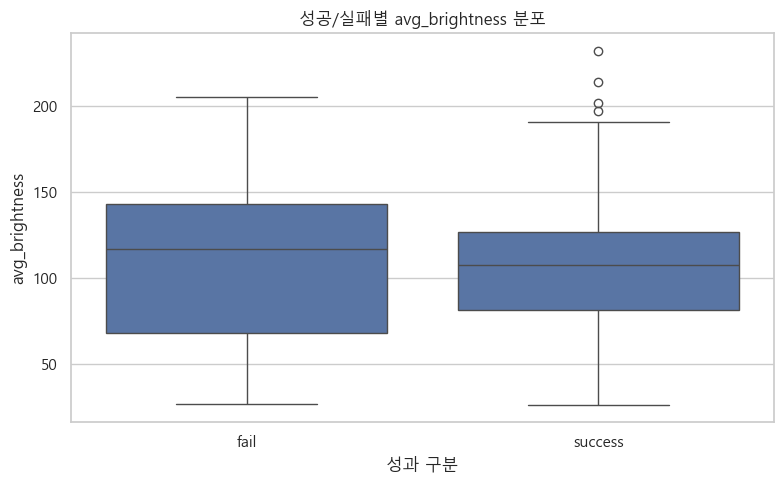

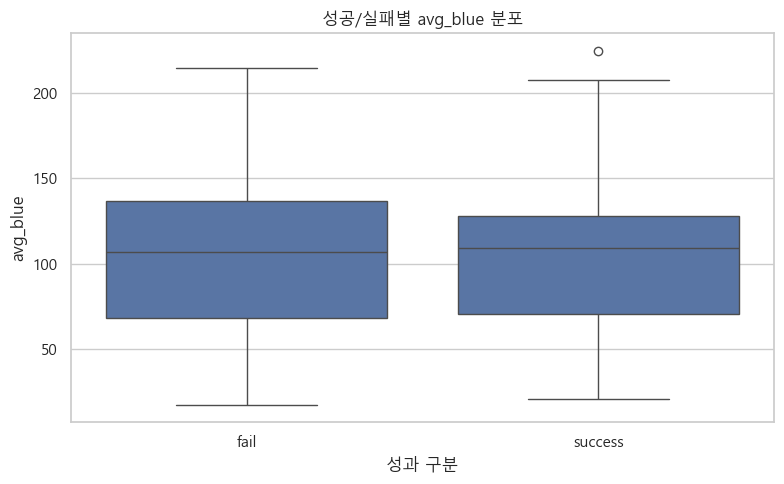

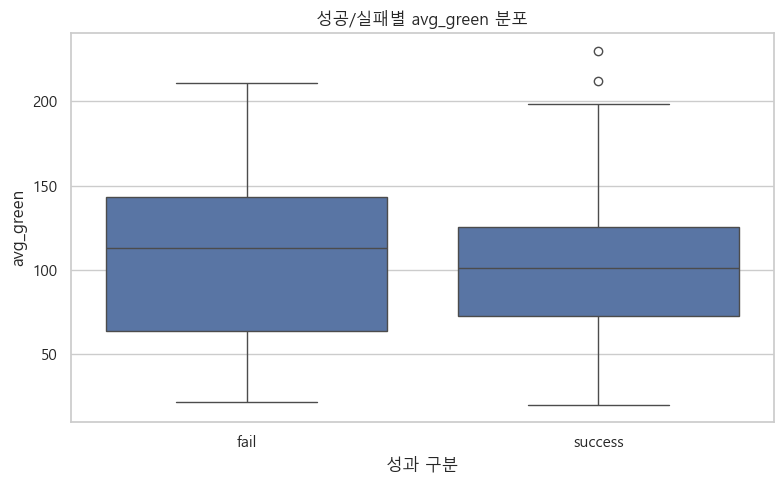

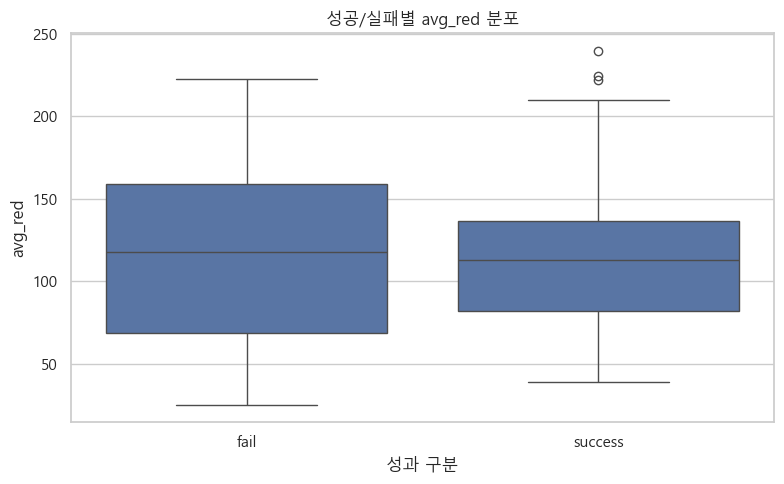

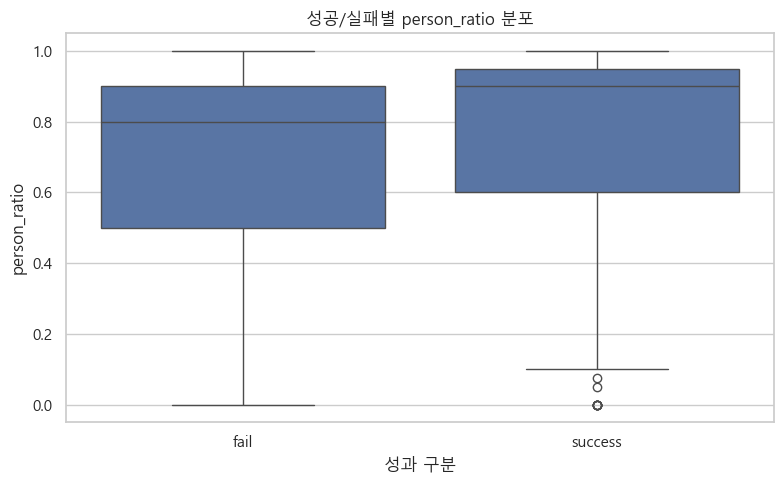

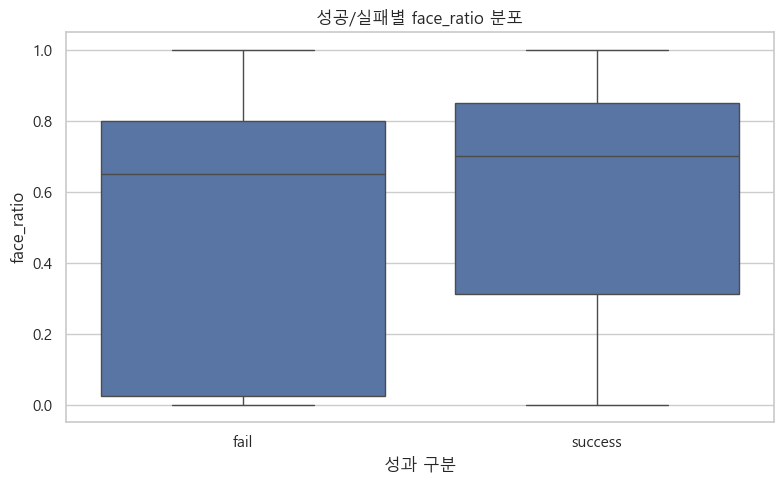

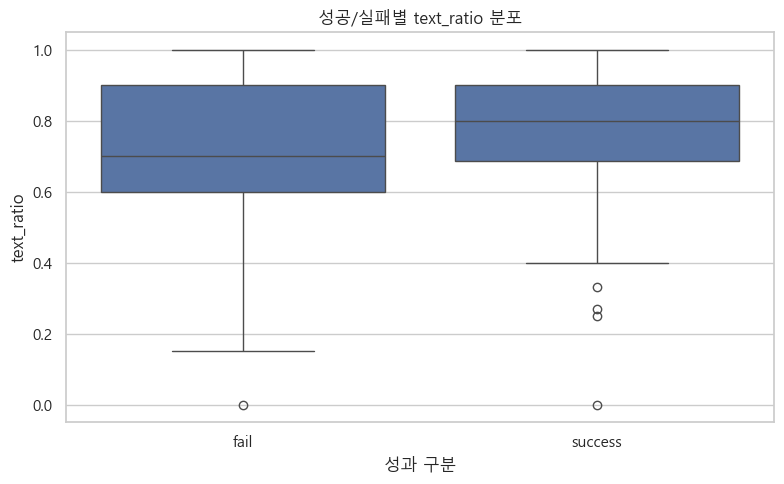

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df,
        x="success_label",
        y=col
    )
    plt.title(f"성공/실패별 {col} 분포")
    plt.xlabel("성과 구분")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

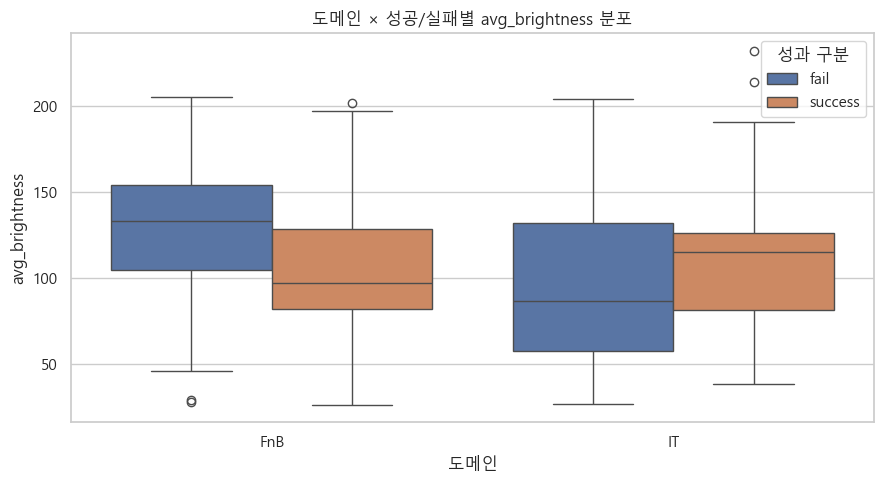

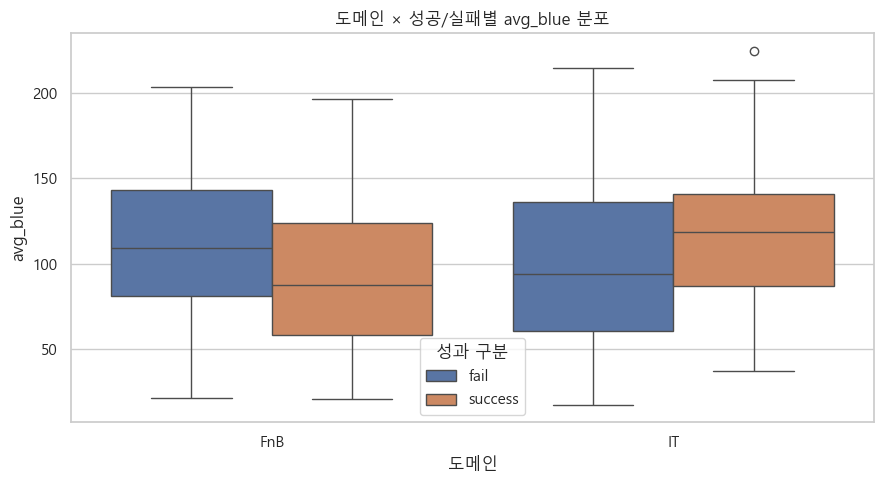

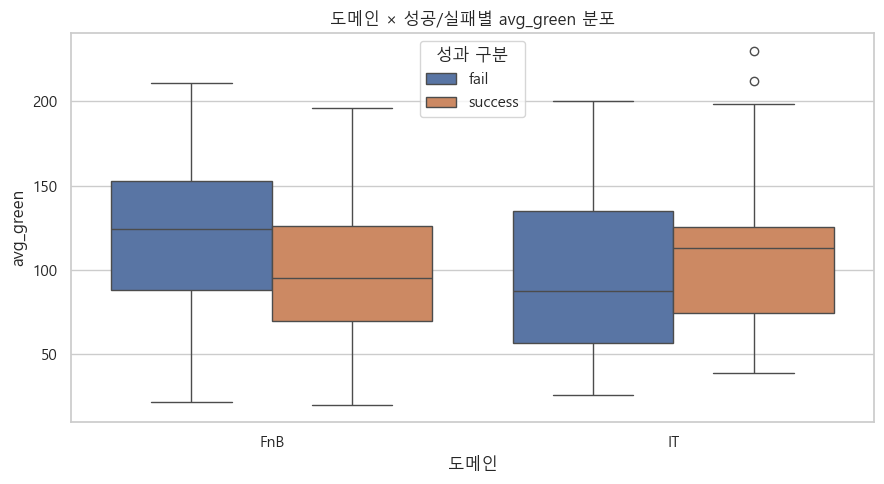

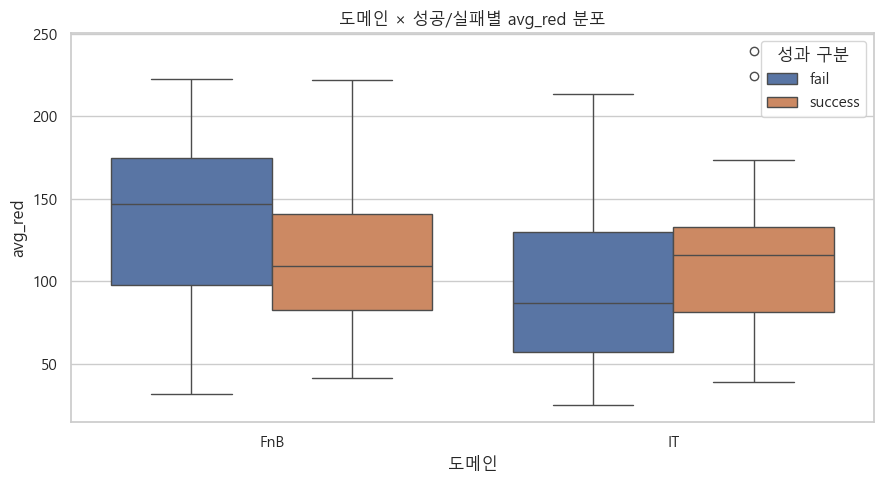

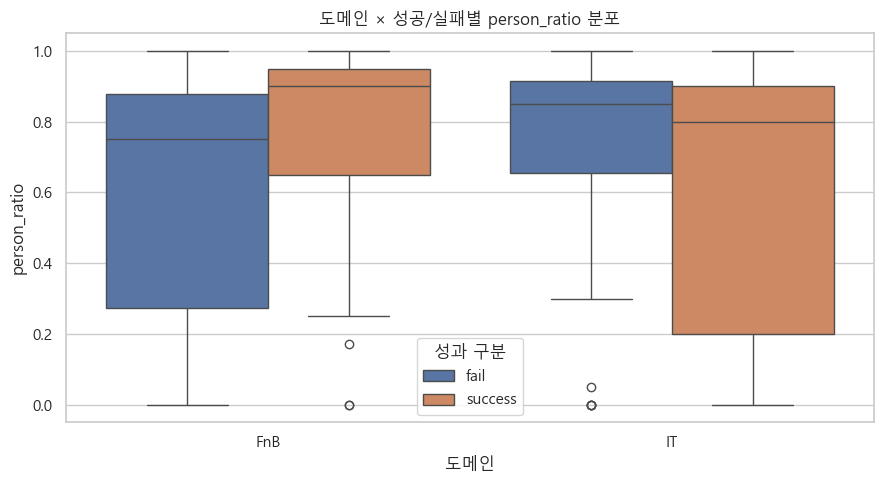

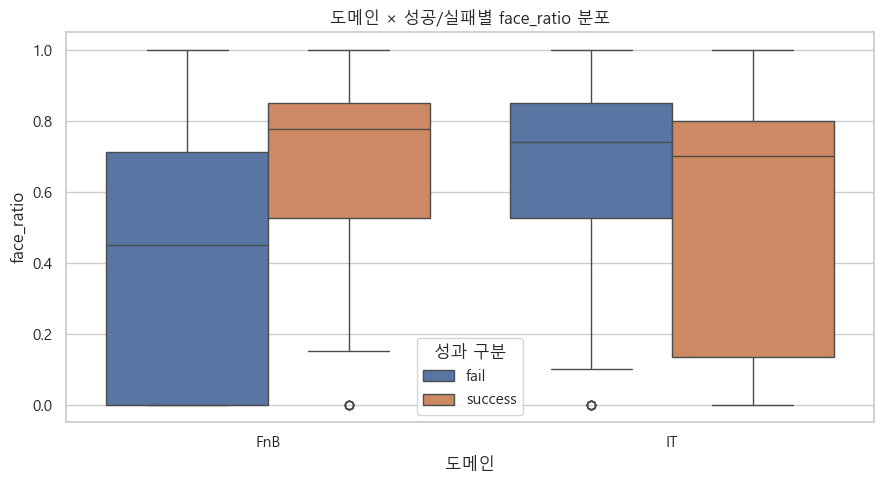

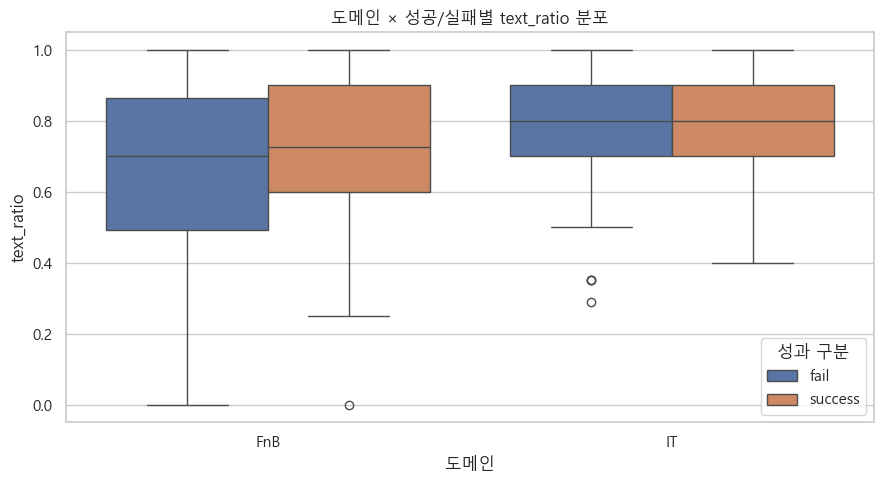

In [7]:
# 조금 더 자세히 보려면 도메인까지 나눠서 봐.
for col in numeric_cols:
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=df,
        x="domain",
        y=col,
        hue="success_label"
    )
    plt.title(f"도메인 × 성공/실패별 {col} 분포")
    plt.xlabel("도메인")
    plt.ylabel(col)
    plt.legend(title="성과 구분")
    plt.tight_layout()
    plt.show()

# 5. 수치형 평균 비교 막대그래프

In [8]:
numeric_mean_long = (
    df.groupby(["domain", "success_label"])[numeric_cols]
      .mean()
      .reset_index()
      .melt(
          id_vars=["domain", "success_label"],
          value_vars=numeric_cols,
          var_name="feature",
          value_name="mean_value"
      )
)

display(numeric_mean_long.head())

,domain,success_label,feature,mean_value
0,FnB,fail,avg_brightness,124.562308
1,FnB,success,avg_brightness,103.751250
2,IT,fail,avg_brightness,97.767069
3,IT,success,avg_brightness,112.246905
4,FnB,fail,avg_blue,111.943269


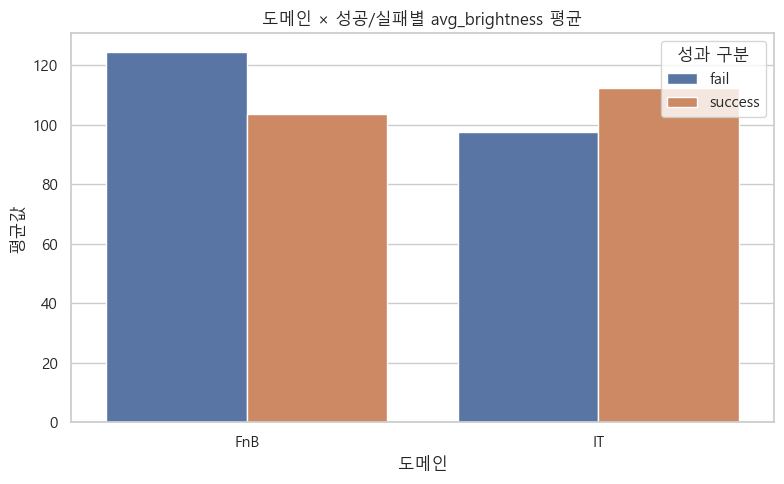

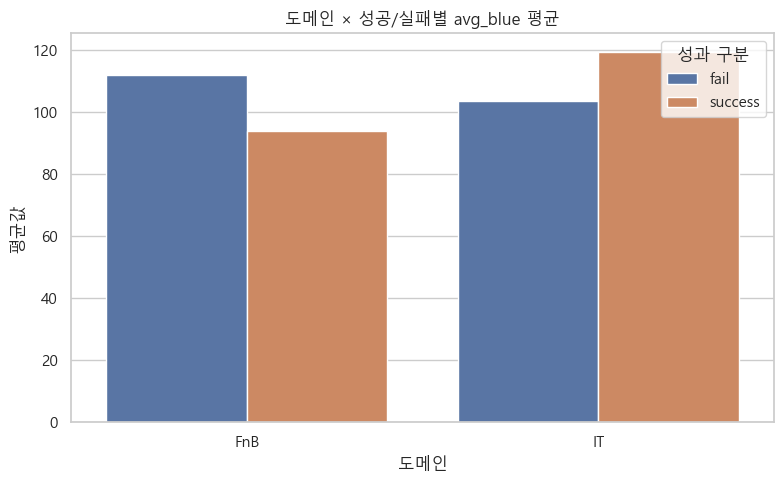

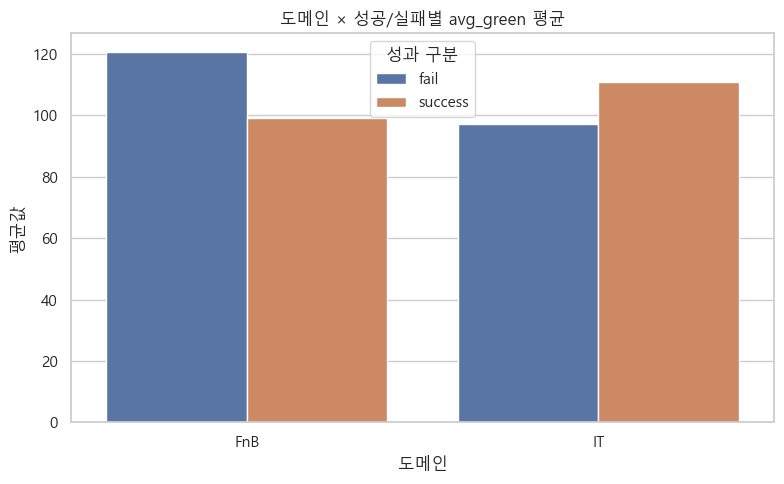

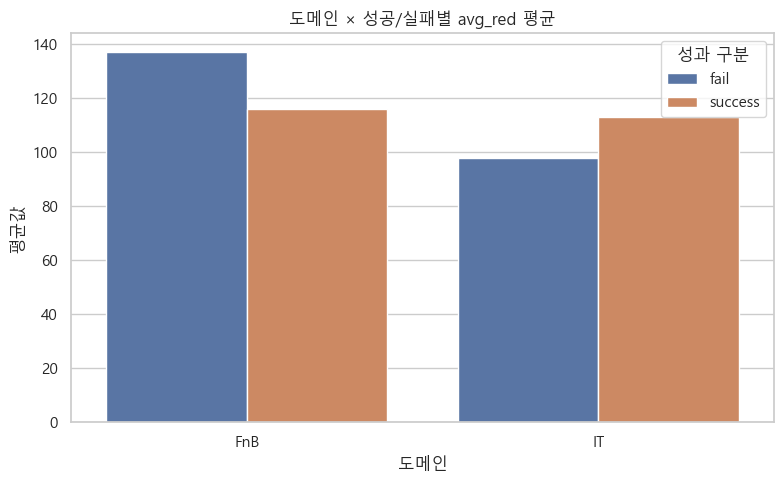

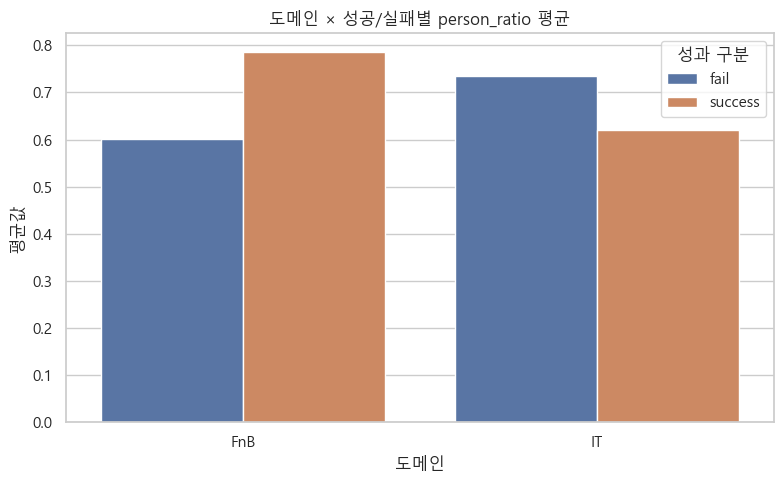

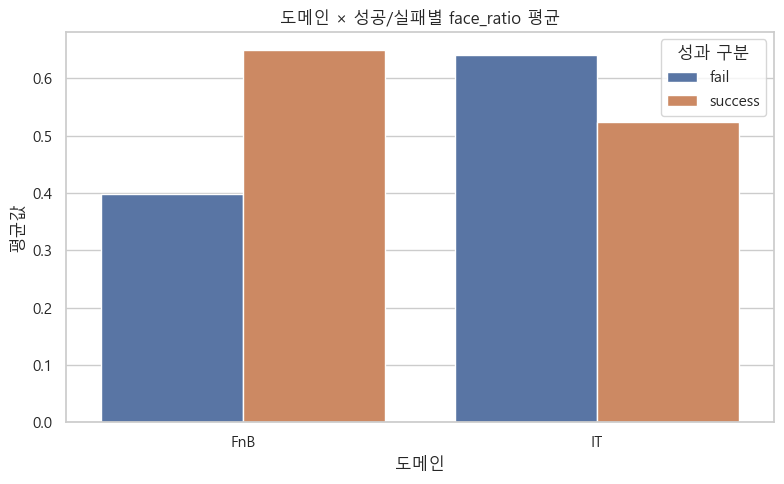

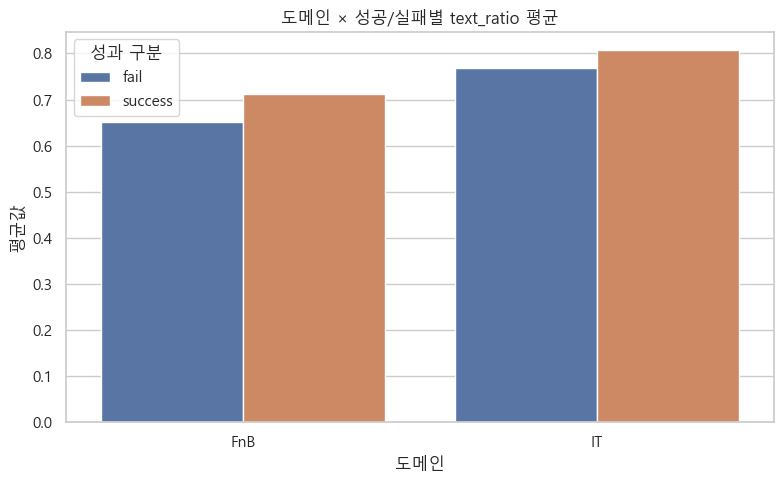

In [9]:
for feature in numeric_cols:
    temp = numeric_mean_long[numeric_mean_long["feature"] == feature]
    
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=temp,
        x="domain",
        y="mean_value",
        hue="success_label"
    )
    plt.title(f"도메인 × 성공/실패별 {feature} 평균")
    plt.xlabel("도메인")
    plt.ylabel("평균값")
    plt.legend(title="성과 구분")
    plt.tight_layout()
    plt.show()

# 6. 성공-실패 차이 시각화


In [10]:
diff_rows = []

for domain in df["domain"].unique():
    temp = df[df["domain"] == domain]
    
    success_mean = temp[temp["success_label"] == "success"][numeric_cols].mean()
    fail_mean = temp[temp["success_label"] == "fail"][numeric_cols].mean()
    
    for col in numeric_cols:
        diff_rows.append({
            "domain": domain,
            "feature": col,
            "success_mean": success_mean[col],
            "fail_mean": fail_mean[col],
            "diff_success_minus_fail": success_mean[col] - fail_mean[col],
        })

numeric_diff_df = pd.DataFrame(diff_rows)

display(numeric_diff_df.round(3))

,domain,feature,success_mean,fail_mean,diff_success_minus_fail
0,FnB,avg_brightness,103.751,124.562,-20.811
1,FnB,avg_blue,93.767,111.943,-18.176
2,FnB,avg_green,99.241,120.713,-21.471
3,FnB,avg_red,115.789,137.047,-21.258
4,FnB,person_ratio,0.786,0.602,0.185
5,FnB,face_ratio,0.649,0.399,0.250
6,FnB,text_ratio,0.712,0.652,0.060
7,IT,avg_brightness,112.247,97.767,14.480
8,IT,avg_blue,119.381,103.477,15.904
9,IT,avg_green,110.782,97.262,13.520


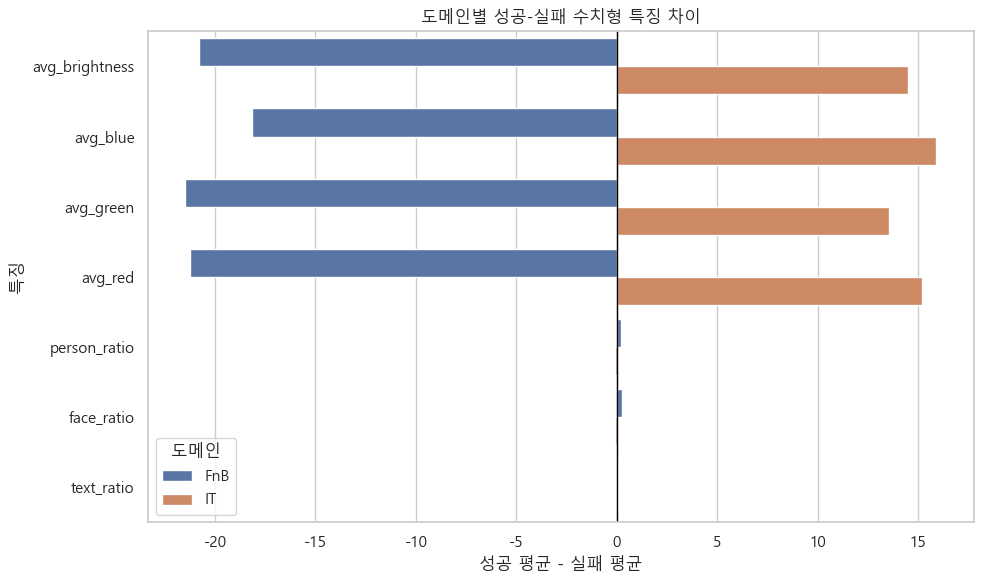

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=numeric_diff_df,
    x="diff_success_minus_fail",
    y="feature",
    hue="domain"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("도메인별 성공-실패 수치형 특징 차이")
plt.xlabel("성공 평균 - 실패 평균")
plt.ylabel("특징")
plt.legend(title="도메인")
plt.tight_layout()
plt.show()

# 7. 범주형 변수 전체 분포 시각화


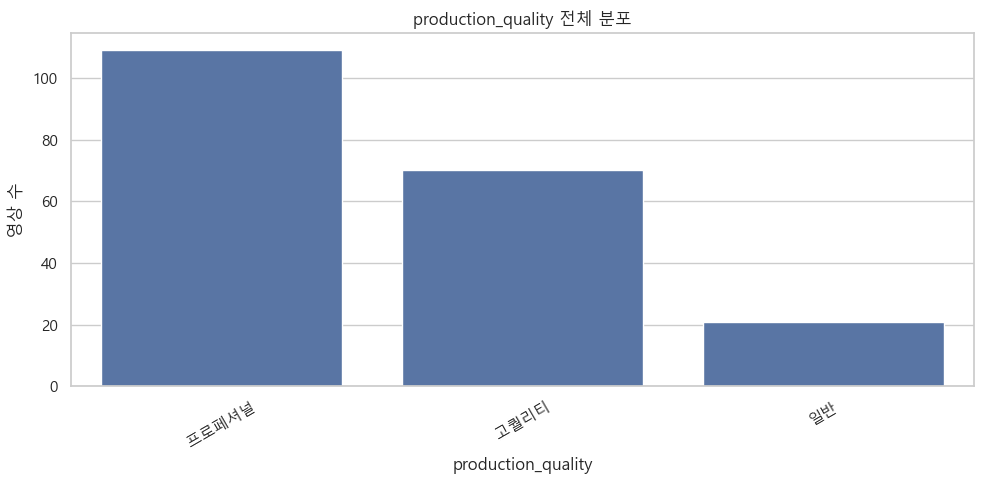

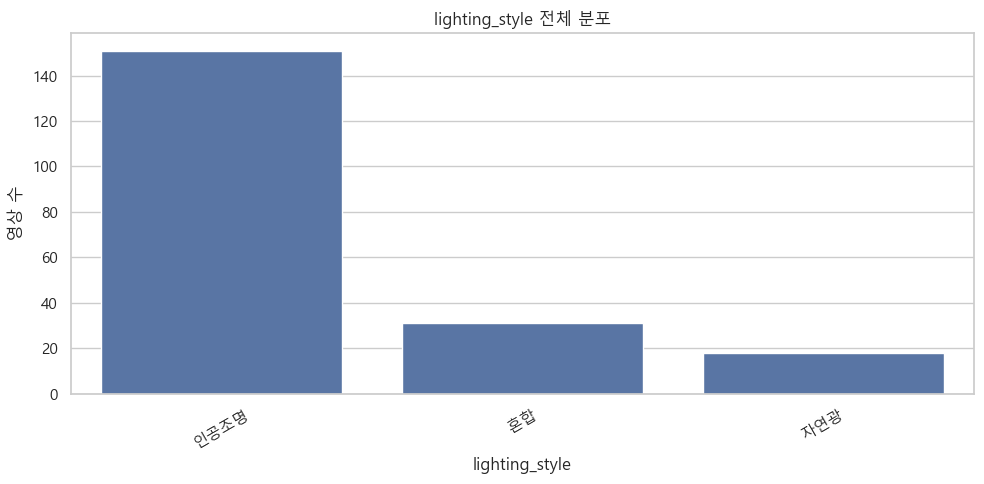

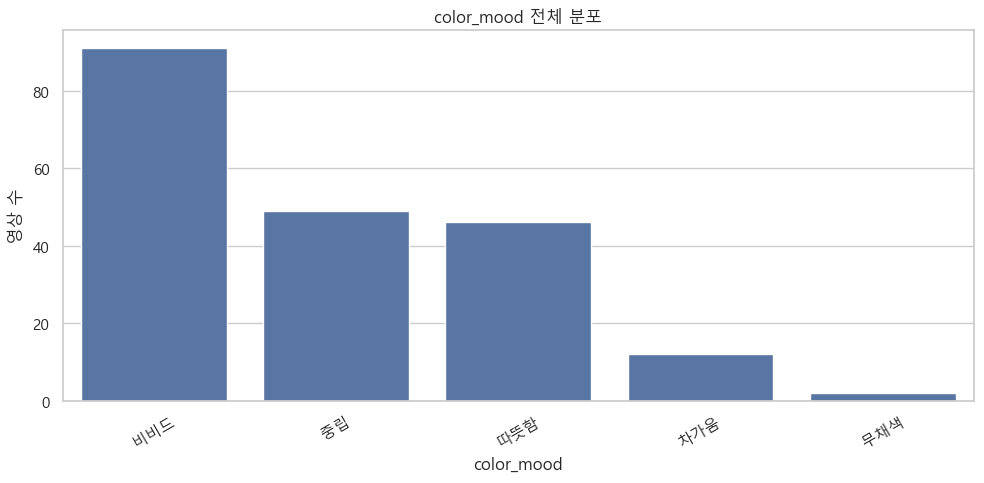

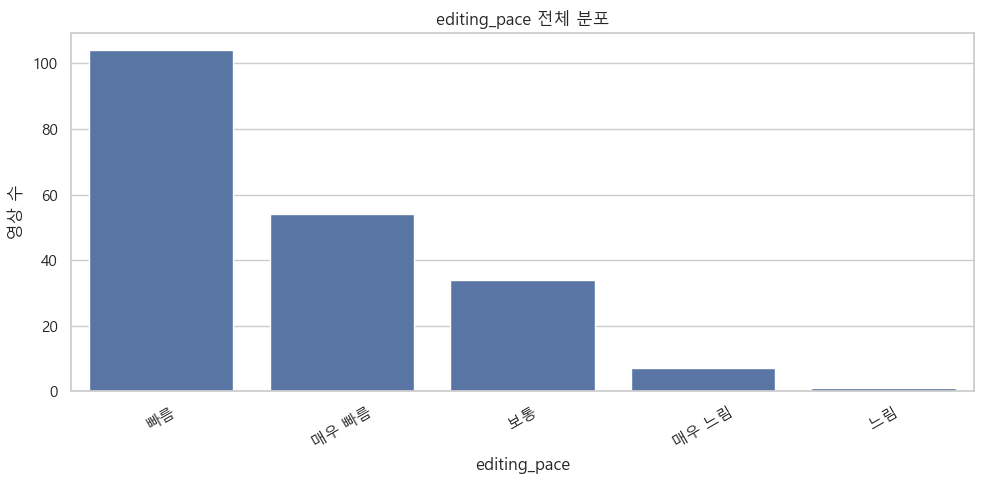

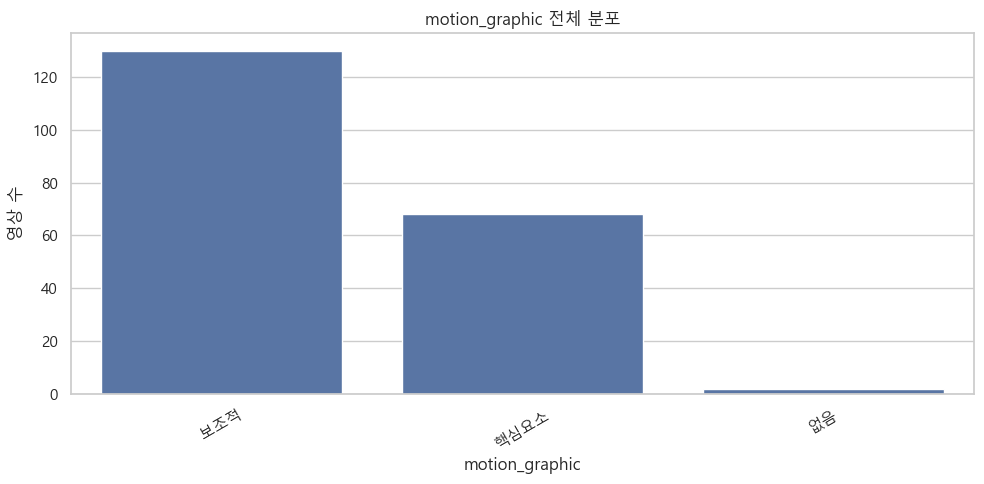

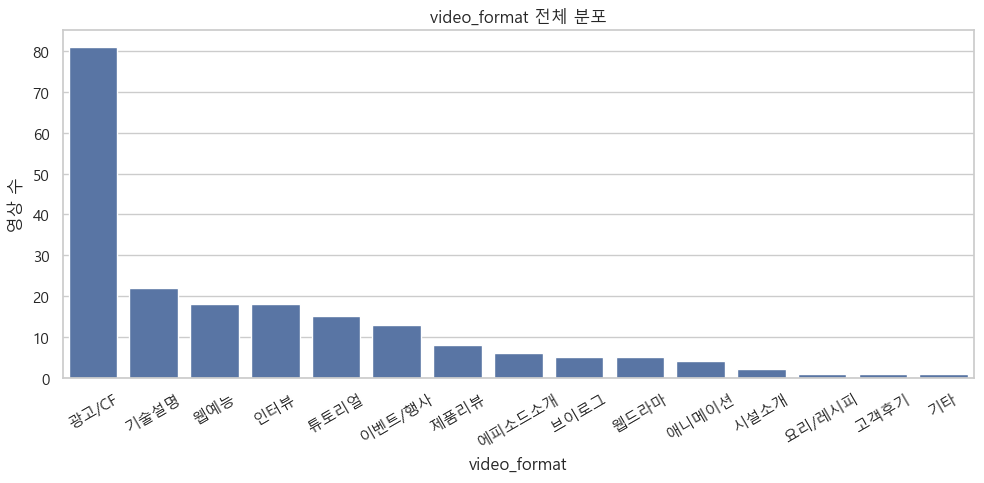

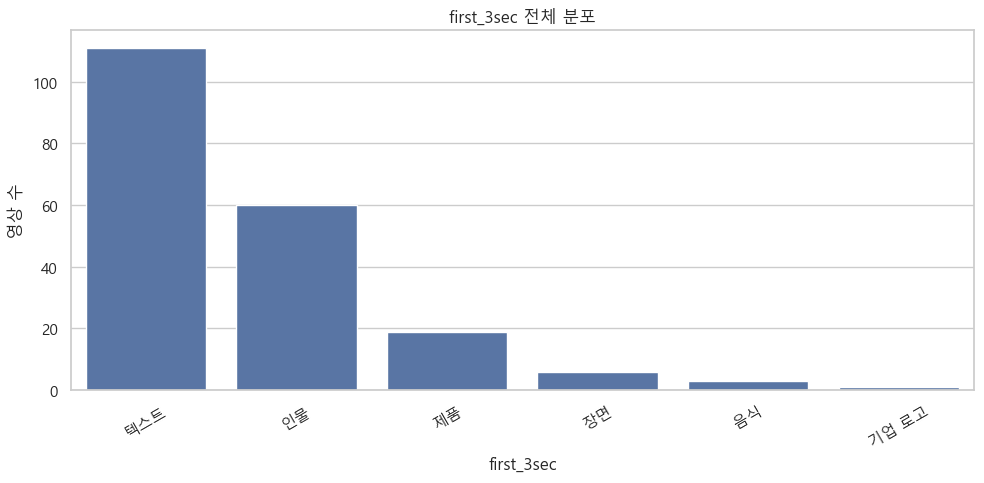

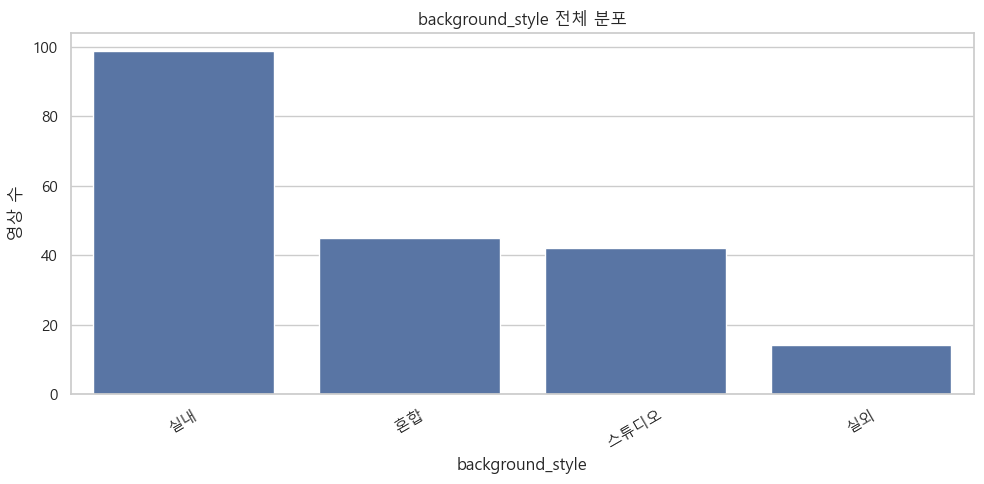

In [16]:
for col in categorical_cols:
    count_df = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )
    count_df.columns = [col, "count"]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=count_df,
        x=col,
        y="count"
    )
    plt.title(f"{col} 전체 분포")
    plt.xlabel(col)
    plt.ylabel("영상 수")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# 8. 도메인 × 성공/실패별 범주 비율 시각화

In [17]:
def make_category_ratio_table(df, category_col, group_cols=["domain", "success_label"]):
    count_df = (
        df.groupby(group_cols + [category_col])
          .size()
          .reset_index(name="count")
    )
    
    total_df = (
        df.groupby(group_cols)
          .size()
          .reset_index(name="total")
    )
    
    result = count_df.merge(total_df, on=group_cols, how="left")
    result["ratio"] = result["count"] / result["total"]
    
    return result

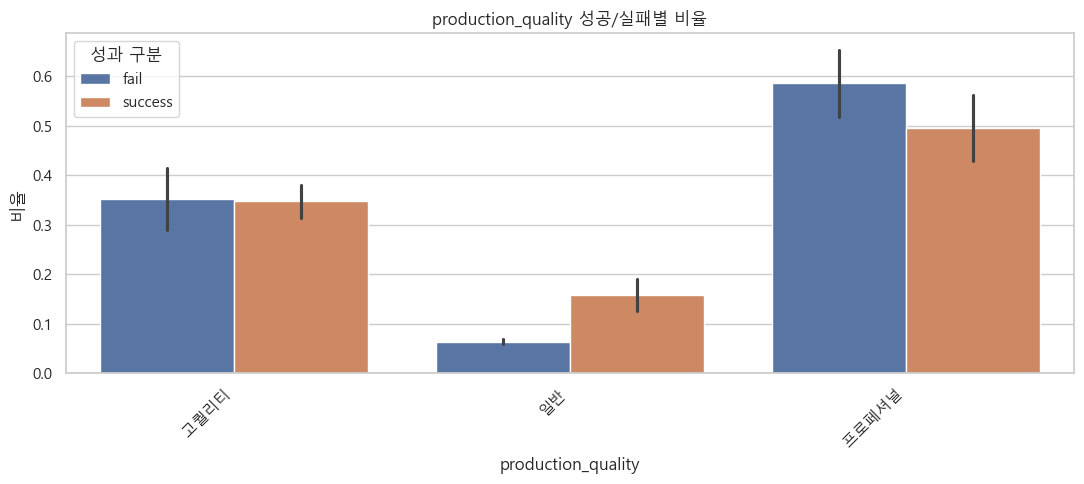

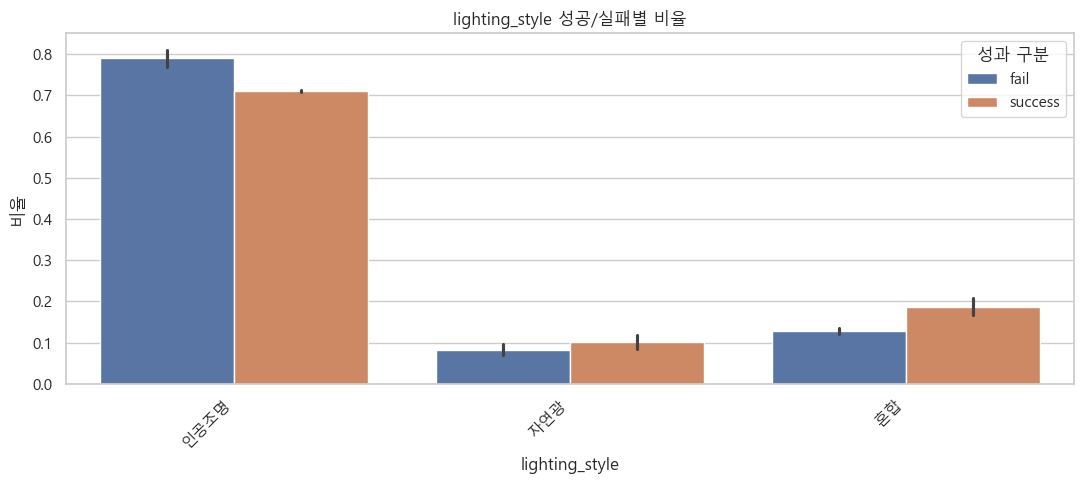

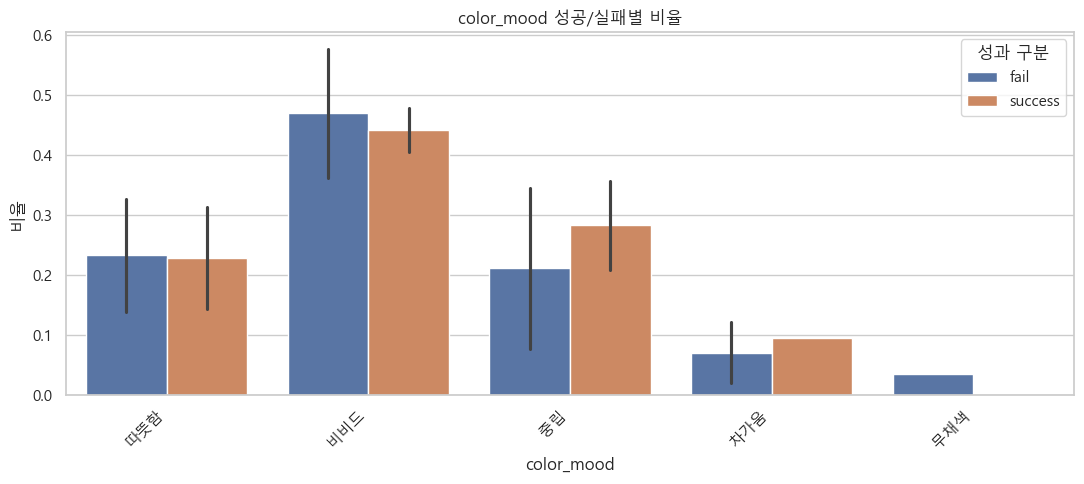

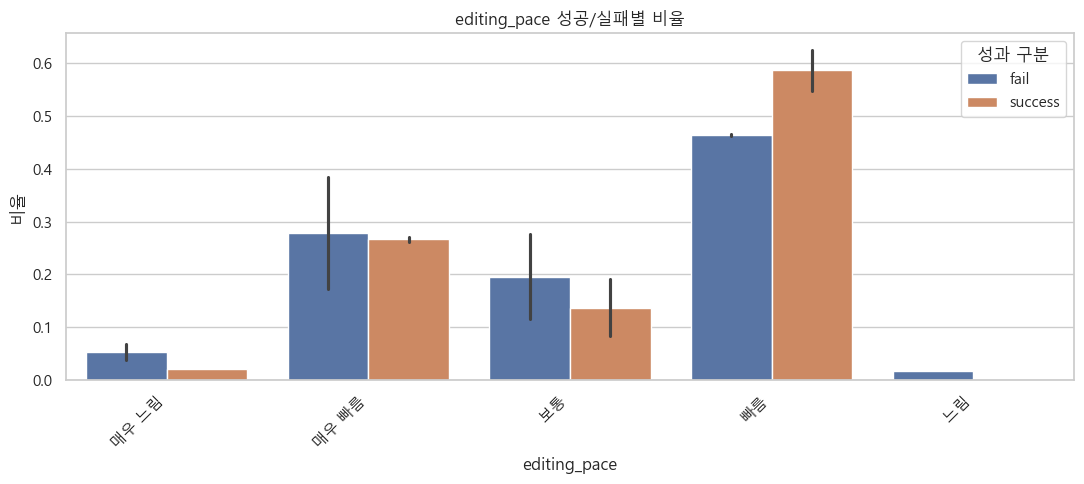

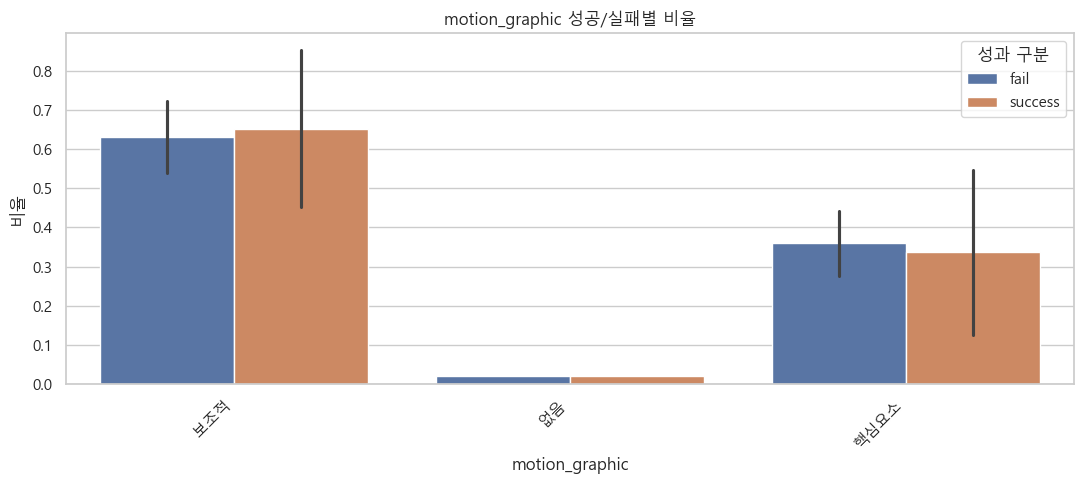

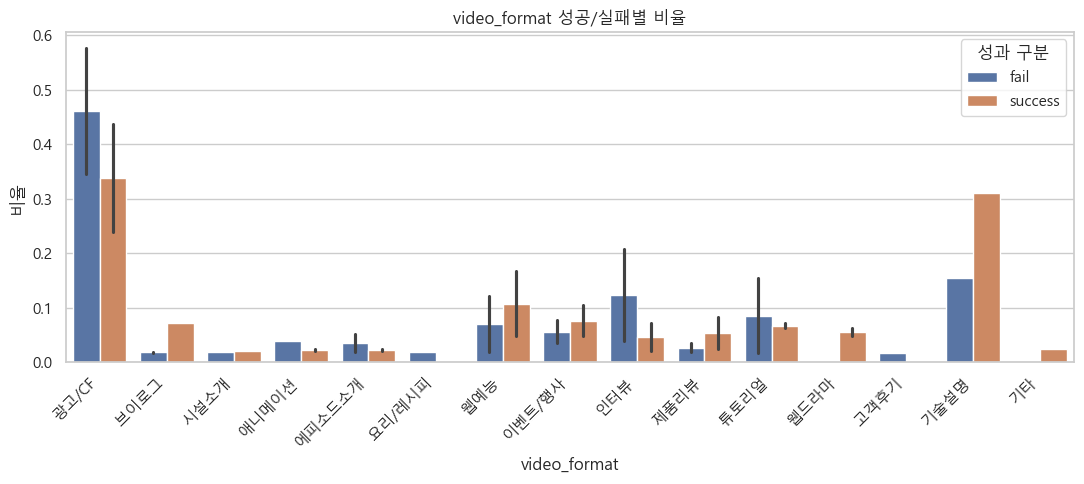

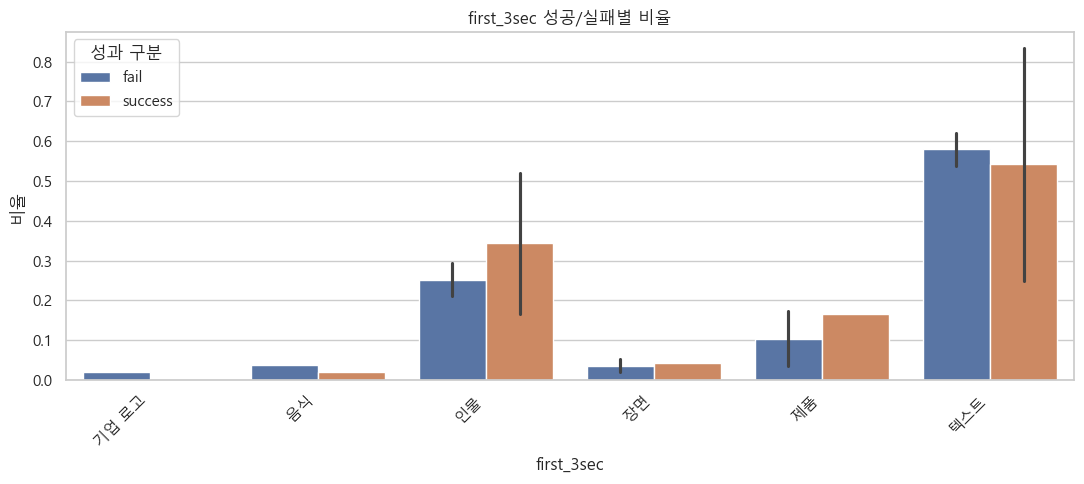

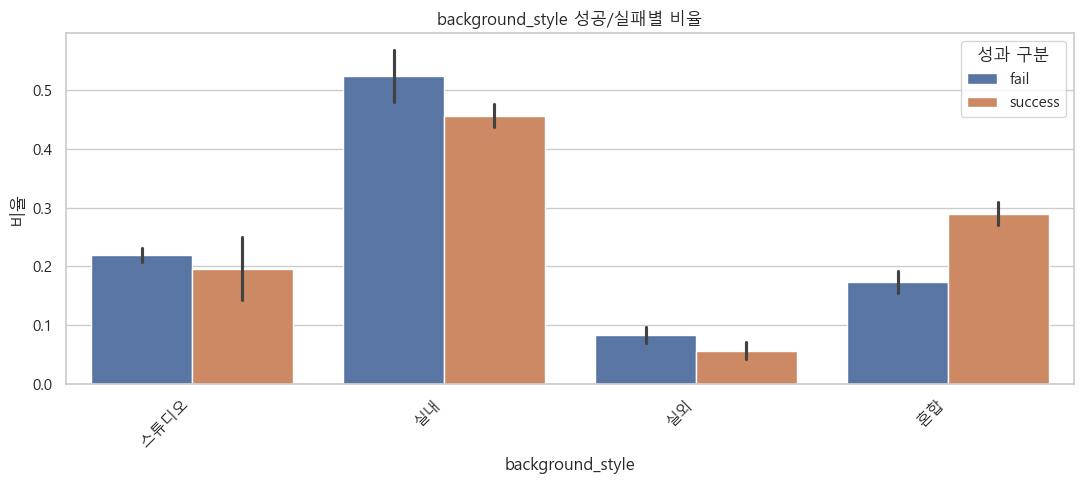

In [18]:
for col in categorical_cols:
    ratio_df = make_category_ratio_table(df, col)
    
    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=ratio_df,
        x=col,
        y="ratio",
        hue="success_label"
    )
    plt.title(f"{col} 성공/실패별 비율")
    plt.xlabel(col)
    plt.ylabel("비율")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="성과 구분")
    plt.tight_layout()
    plt.show()

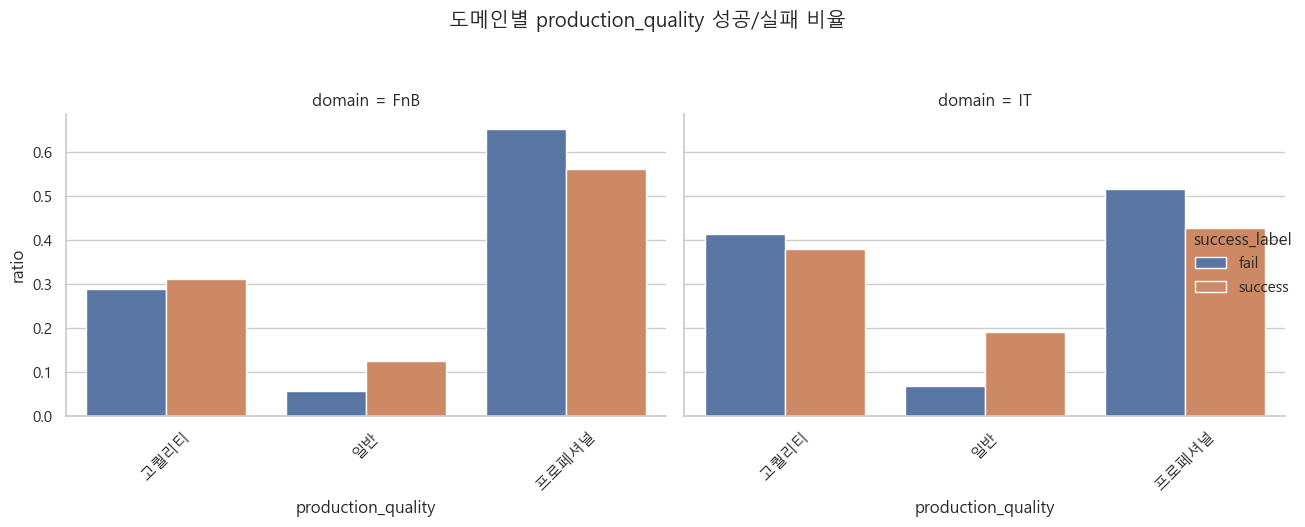

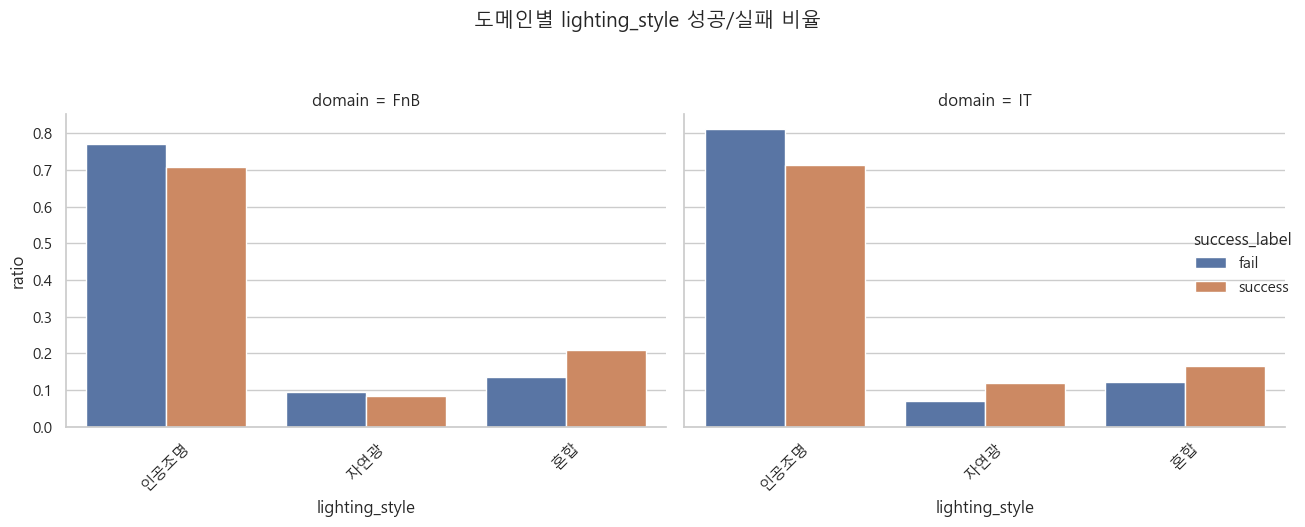

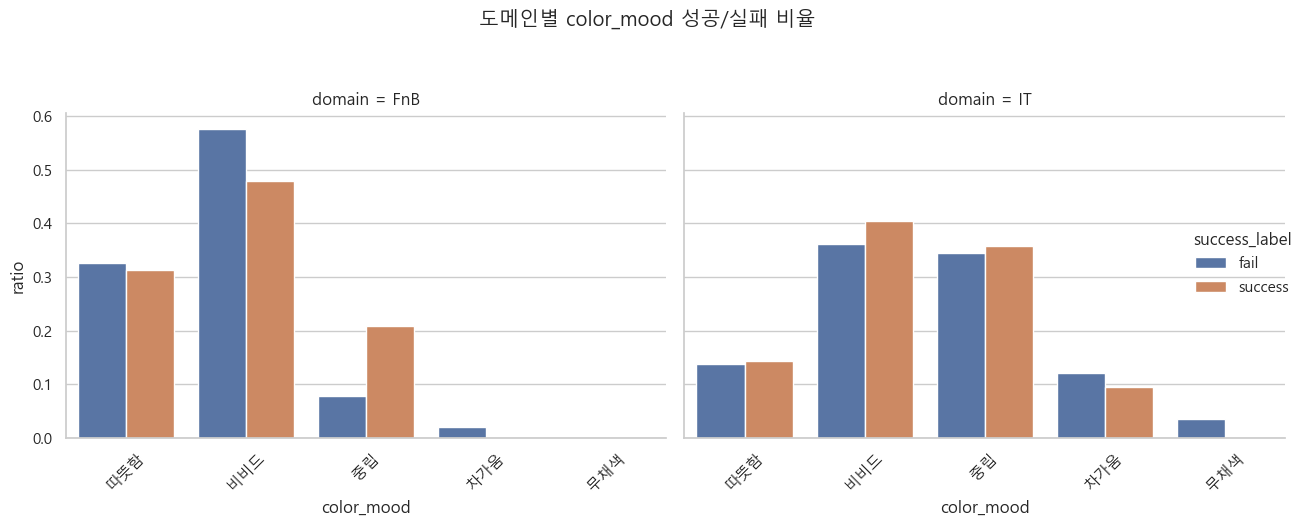

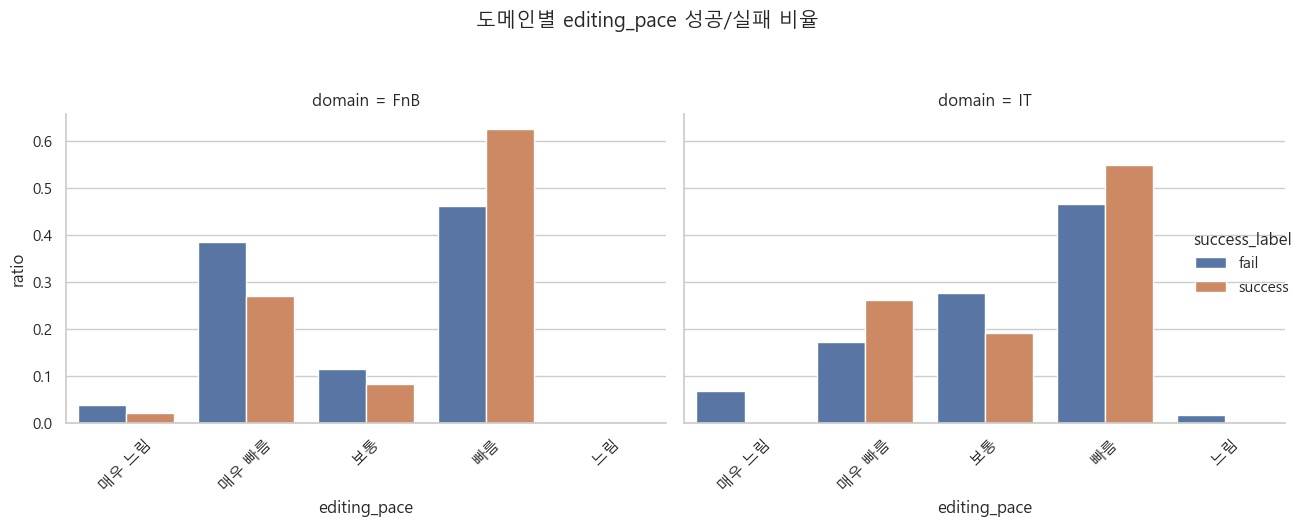

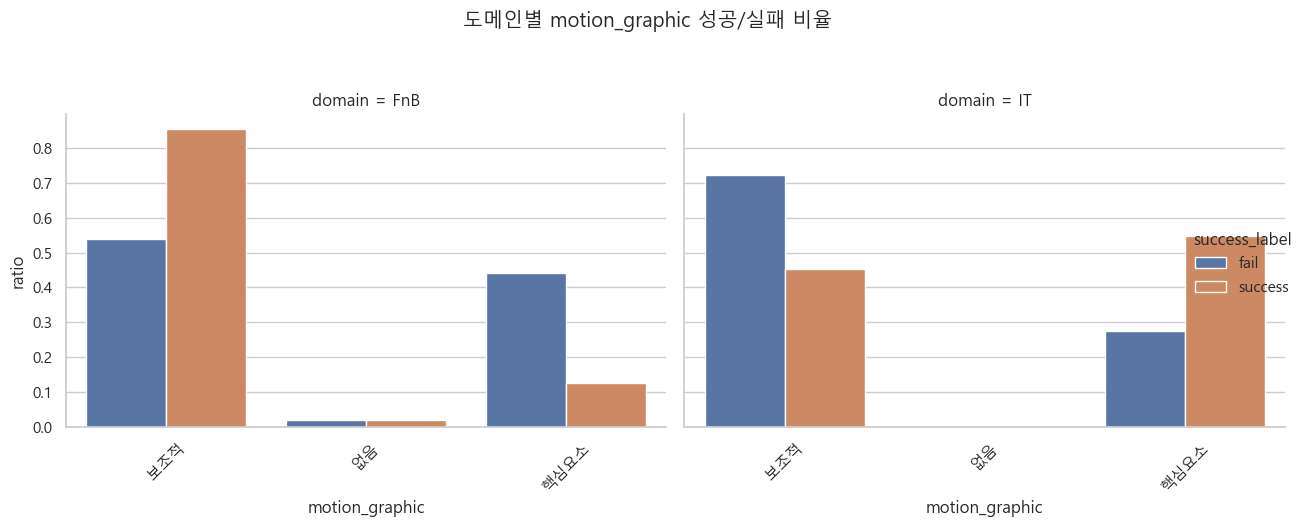

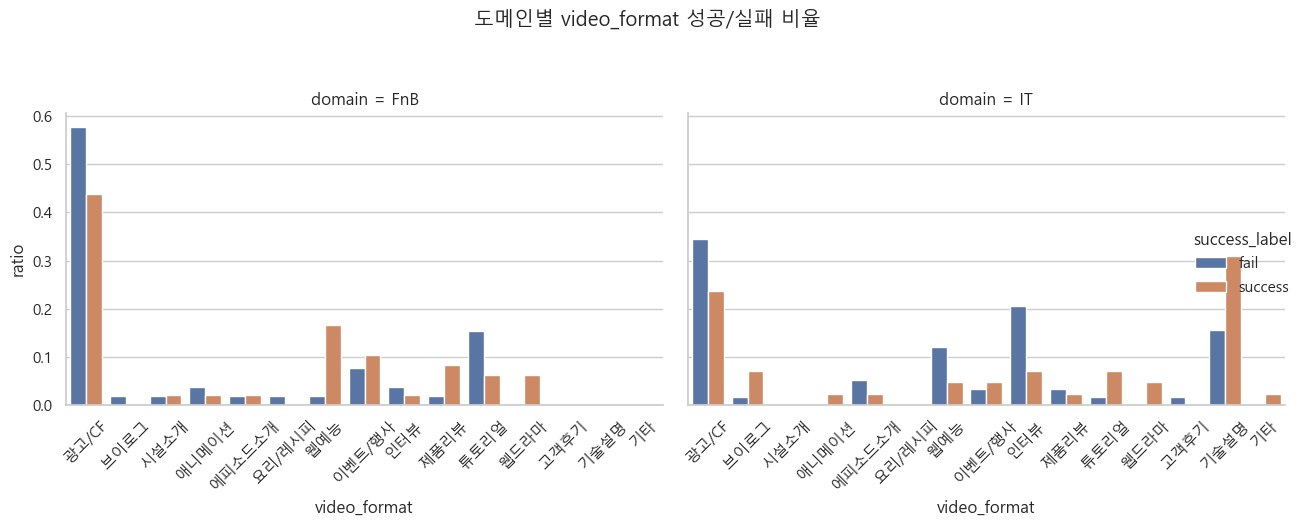

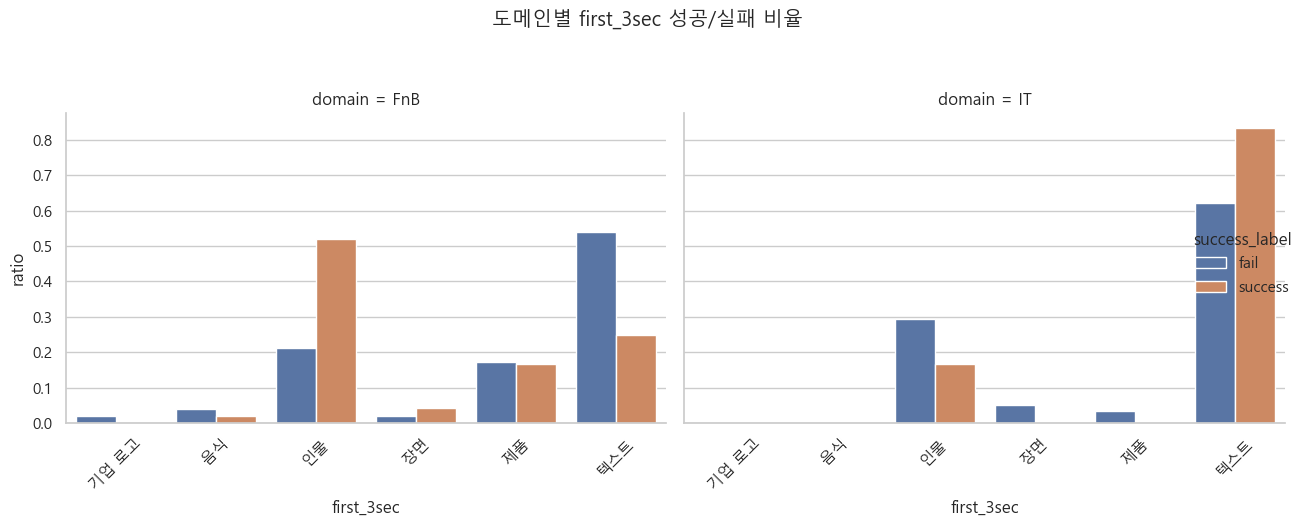

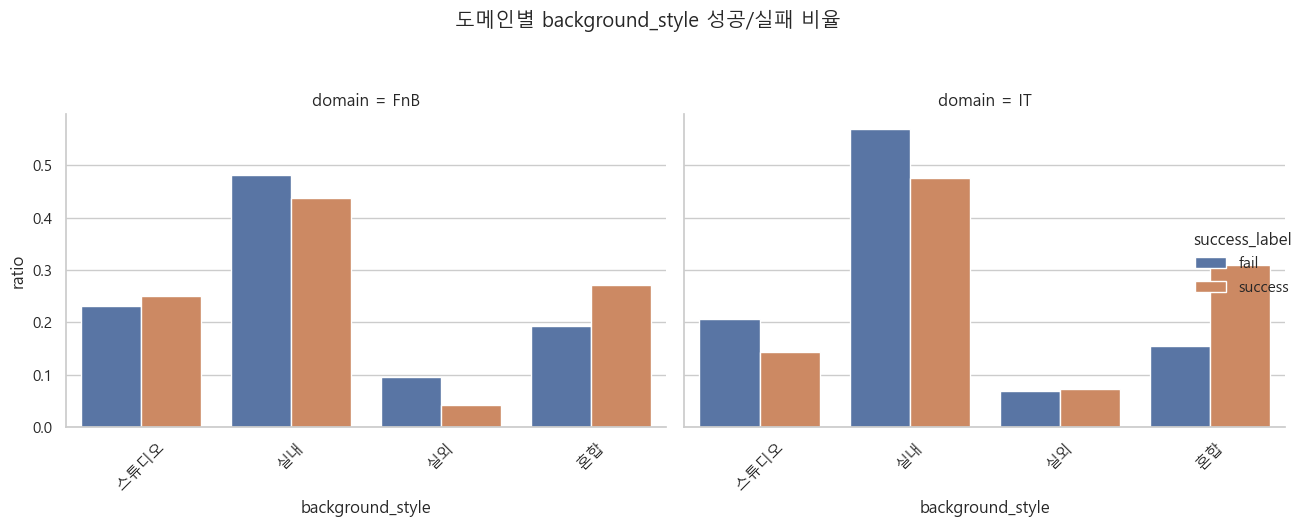

In [19]:
for col in categorical_cols:
    ratio_df = make_category_ratio_table(df, col)
    
    g = sns.catplot(
        data=ratio_df,
        x=col,
        y="ratio",
        hue="success_label",
        col="domain",
        kind="bar",
        height=5,
        aspect=1.2,
        sharey=True
    )
    g.fig.suptitle(f"도메인별 {col} 성공/실패 비율", y=1.05)
    
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()

# 9. 핵심 범주형 변수만 집중 시각화


# 10. 성공-실패 차이가 큰 범주 시각화

In [20]:
def make_success_fail_category_diff(df, category_col):
    ratio_df = make_category_ratio_table(df, category_col)
    
    pivot = ratio_df.pivot_table(
        index=["domain", category_col],
        columns="success_label",
        values="ratio",
        fill_value=0
    ).reset_index()
    
    if "success" not in pivot.columns:
        pivot["success"] = 0
    if "fail" not in pivot.columns:
        pivot["fail"] = 0
    
    pivot["diff_success_minus_fail"] = pivot["success"] - pivot["fail"]
    
    return pivot

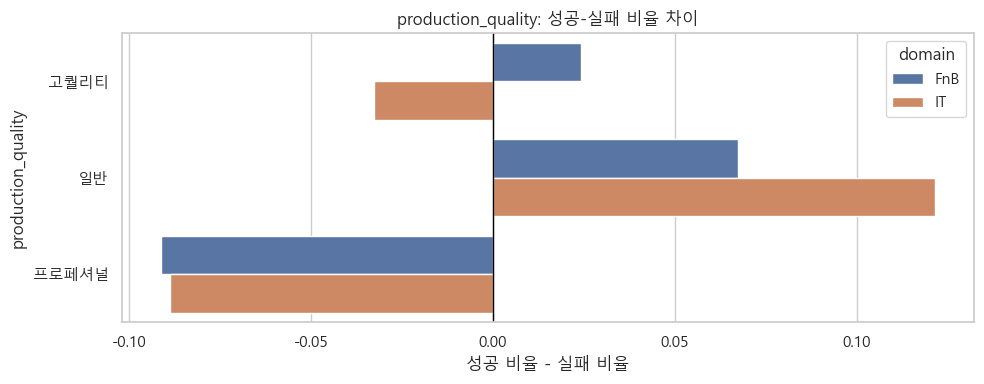

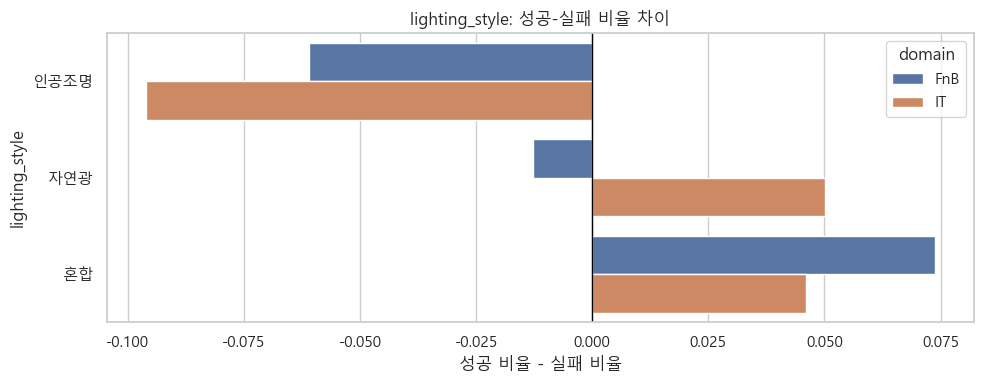

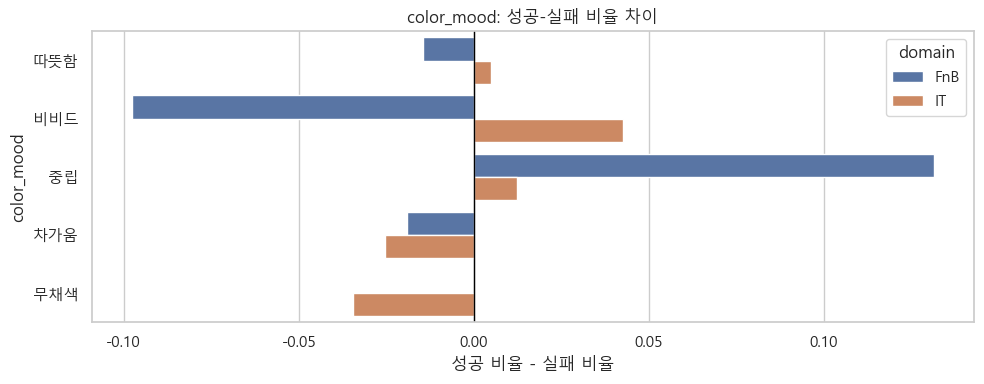

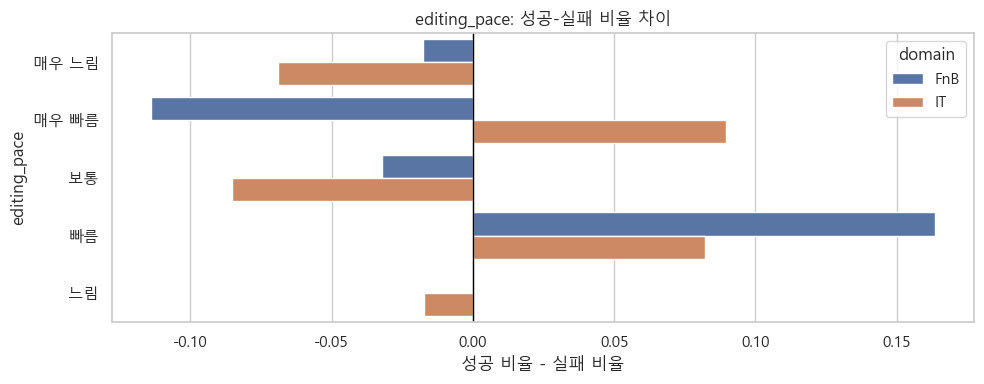

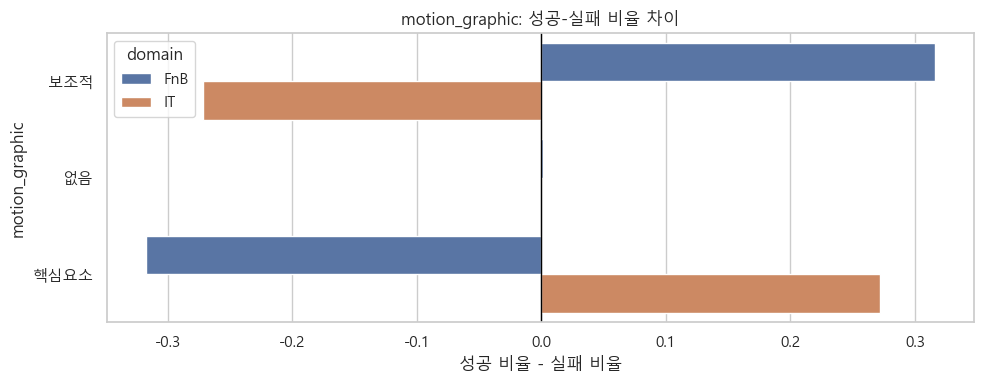

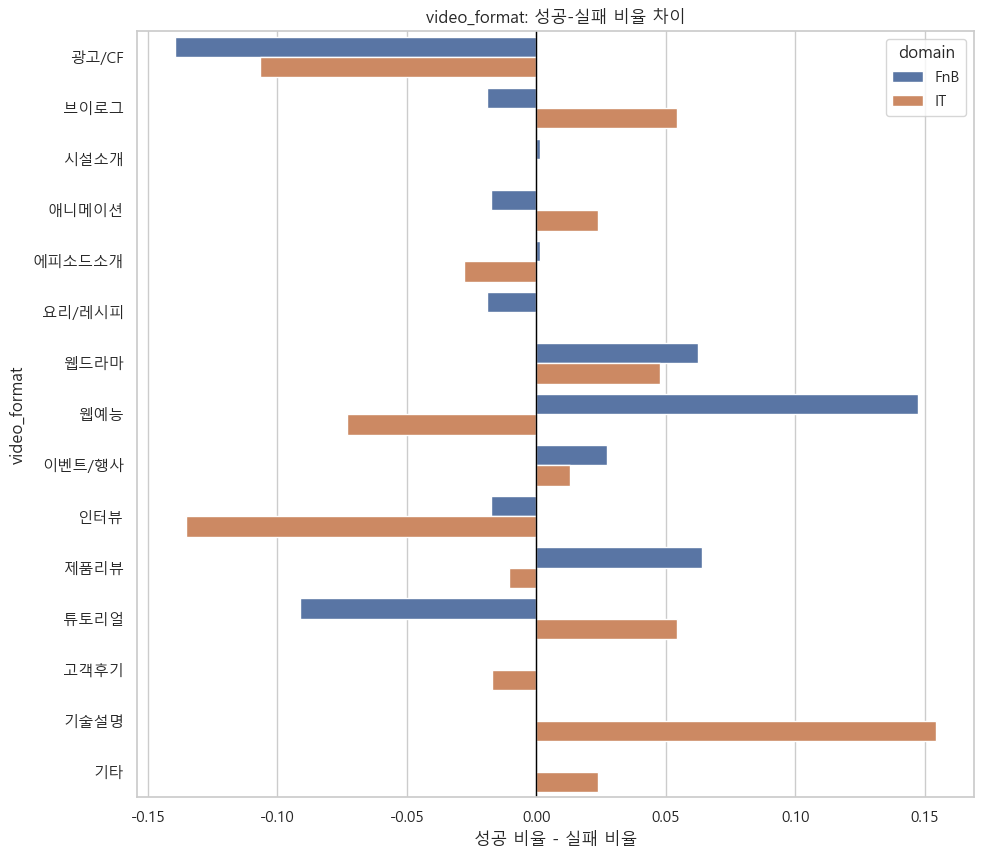

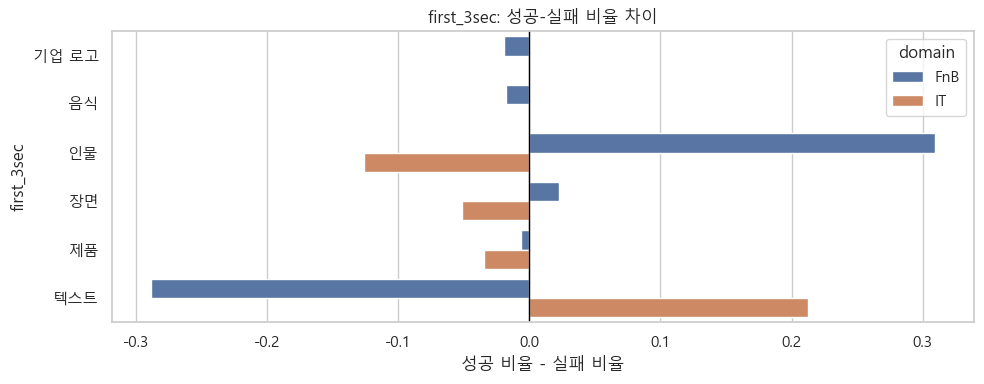

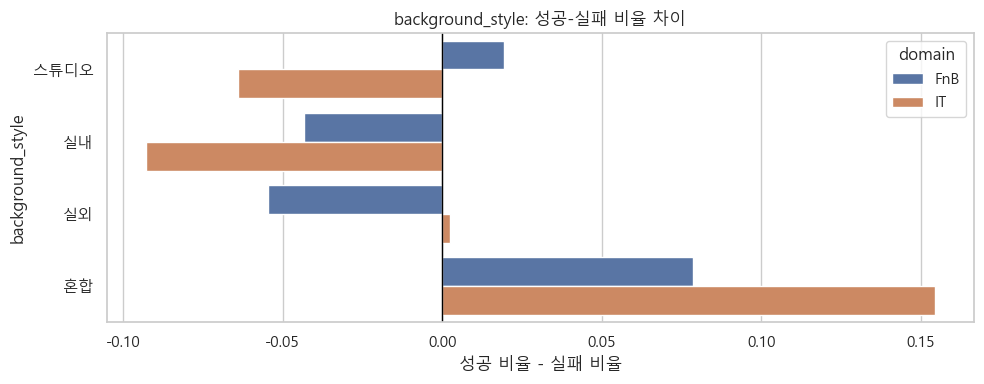

In [21]:
category_diff_dict = {}

for col in categorical_cols:
    diff_table = make_success_fail_category_diff(df, col)
    category_diff_dict[col] = diff_table
    
    plt.figure(figsize=(10, max(4, len(diff_table) * 0.35)))
    sns.barplot(
        data=diff_table,
        x="diff_success_minus_fail",
        y=col,
        hue="domain"
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"{col}: 성공-실패 비율 차이")
    plt.xlabel("성공 비율 - 실패 비율")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# 11. top_colors 시각화

In [23]:
def parse_top_colors(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return parsed
        return [str(parsed)]
    except:
        return [str(x)]

df["top_colors_parsed"] = df["top_colors"].apply(parse_top_colors)

In [24]:
color_rows = []

for (domain, success_label), group in df.groupby(["domain", "success_label"]):
    colors = []
    
    for color_list in group["top_colors_parsed"]:
        colors.extend(color_list)
    
    counter = Counter(colors)
    total = sum(counter.values())
    
    for color, count in counter.most_common(10):
        color_rows.append({
            "domain": domain,
            "success_label": success_label,
            "color": color,
            "count": count,
            "ratio": count / total if total > 0 else 0
        })

color_summary = pd.DataFrame(color_rows)

display(color_summary)

,domain,success_label,color,count,ratio
0,FnB,fail,흰색,41,0.262821
1,FnB,fail,빨간색,17,0.108974
2,FnB,fail,갈색,17,0.108974
3,FnB,fail,노란색,16,0.102564
4,FnB,fail,파란색,12,0.076923
5,FnB,fail,검은색,11,0.070513
6,FnB,fail,주황색,8,0.051282
7,FnB,fail,회색,7,0.044872
8,FnB,fail,초록색,6,0.038462
9,FnB,fail,분홍색,3,0.019231


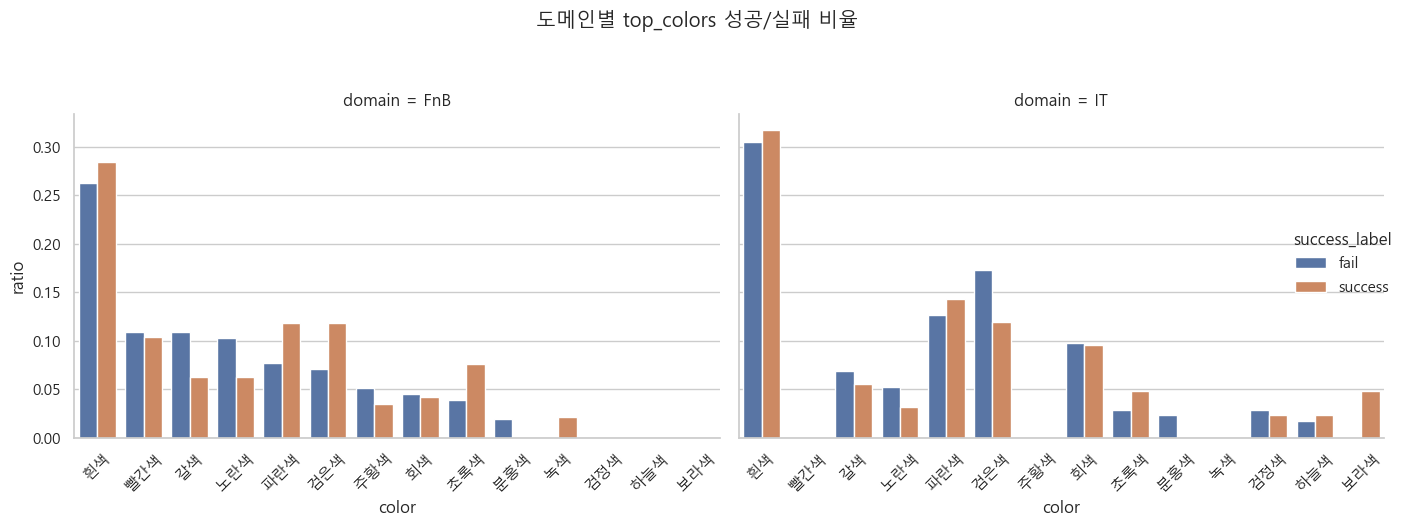

In [25]:
g = sns.catplot(
    data=color_summary,
    x="color",
    y="ratio",
    hue="success_label",
    col="domain",
    kind="bar",
    height=5,
    aspect=1.3,
    sharey=True
)

g.fig.suptitle("도메인별 top_colors 성공/실패 비율", y=1.05)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 12. 더 자세한 EDA: 성과지표와 시각 특징 관계

In [26]:
performance_cols = [
    "조회수",
    "좋아요수",
    "댓글수",
    "참여율(ER)",
    "도달률(RR)",
    "일평균 조회수",
    "score1",
    "score2",
]

performance_cols = [col for col in performance_cols if col in df.columns]

print(performance_cols)

['조회수', '좋아요수', '댓글수', '참여율(ER)', '도달률(RR)', '일평균 조회수', 'score1', 'score2']


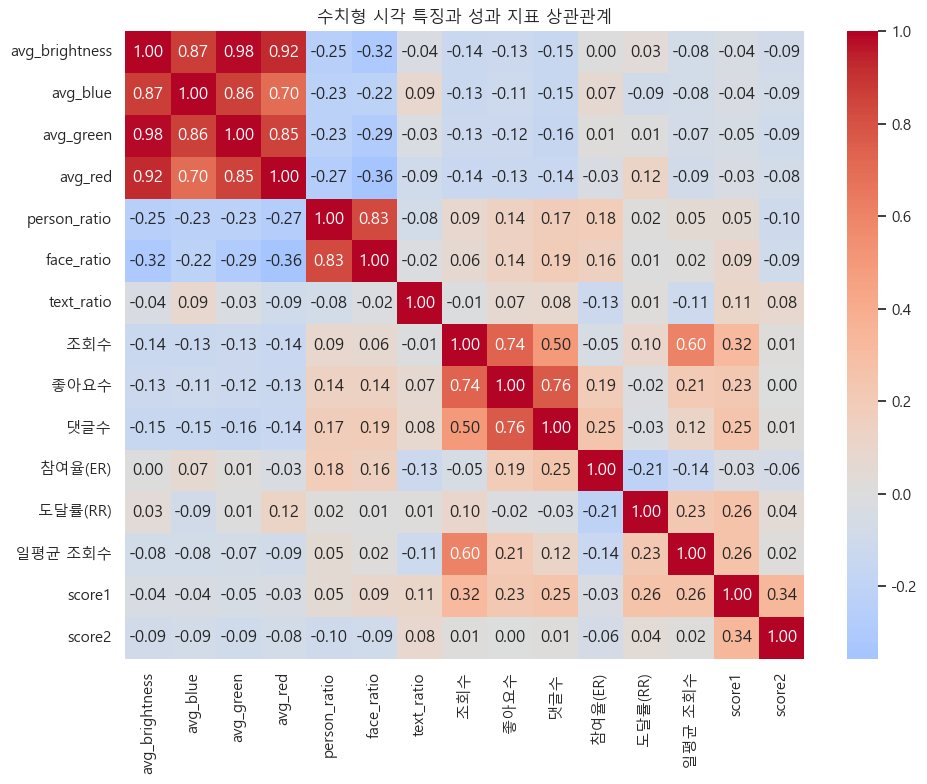

In [27]:
corr_cols = numeric_cols + performance_cols

corr_df = df[corr_cols].corr(numeric_only=True).round(3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("수치형 시각 특징과 성과 지표 상관관계")
plt.tight_layout()
plt.show()

# 13. 더 자세한 EDA: 채널 규모별 차이

In [28]:
if "channel_tier" in df.columns:
    display(df["channel_tier"].value_counts(dropna=False))

channel_tier
micro    59
macro    40
nano     38
mid      37
mega     17
pico      9
Name: count, dtype: int64

In [29]:
if "channel_tier" in df.columns:
    tier_summary = (
        df.groupby(["domain", "success_label", "channel_tier"])[numeric_cols]
          .mean()
          .round(3)
          .reset_index()
    )
    
    display(tier_summary)

,domain,success_label,channel_tier,avg_brightness,avg_blue,avg_green,avg_red,person_ratio,face_ratio,text_ratio
0,FnB,fail,macro,118.077,111.006,116.398,123.914,0.705,0.537,0.667
1,FnB,fail,mega,123.302,122.803,121.670,127.452,0.592,0.467,0.725
2,FnB,fail,micro,109.202,92.549,96.146,141.731,0.456,0.225,0.662
3,FnB,fail,mid,160.805,130.050,157.125,179.894,0.465,0.135,0.563
4,FnB,fail,nano,67.690,46.170,63.880,83.230,0.400,0.300,0.600
5,FnB,success,macro,95.881,89.767,91.074,104.569,0.929,0.821,0.843
6,FnB,success,mega,88.400,86.554,87.830,87.346,0.940,0.840,0.710
7,FnB,success,micro,87.570,85.650,83.418,97.613,0.713,0.652,0.583
8,FnB,success,mid,87.300,72.602,82.644,102.024,0.770,0.640,0.620
9,FnB,success,nano,121.565,109.810,117.261,134.400,0.701,0.605,0.739


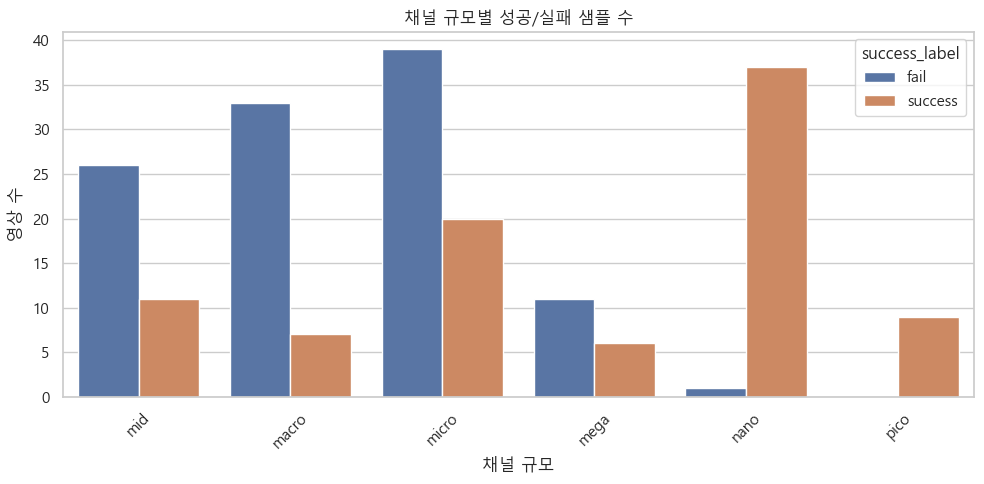

In [30]:
if "channel_tier" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x="channel_tier",
        hue="success_label"
    )
    plt.title("채널 규모별 성공/실패 샘플 수")
    plt.xlabel("채널 규모")
    plt.ylabel("영상 수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 14. 더 자세한 EDA: 업로드 시기별 차이

In [31]:
if "upload_year" in df.columns:
    year_count = (
        df.groupby(["upload_year", "domain", "success_label"])
          .size()
          .reset_index(name="count")
    )
    
    display(year_count)

,upload_year,domain,success_label,count
0,2021.0,FnB,fail,2
1,2022.0,FnB,fail,5
2,2022.0,FnB,success,4
3,2022.0,IT,fail,9
4,2022.0,IT,success,2
5,2023.0,FnB,fail,18
6,2023.0,FnB,success,8
7,2023.0,IT,fail,12
8,2023.0,IT,success,7
9,2024.0,FnB,fail,13


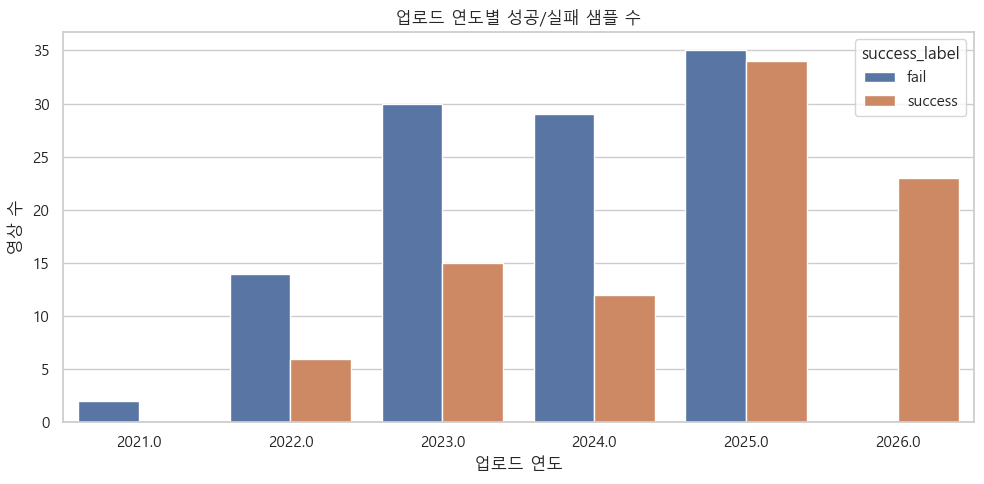

In [32]:
if "upload_year" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x="upload_year",
        hue="success_label"
    )
    plt.title("업로드 연도별 성공/실패 샘플 수")
    plt.xlabel("업로드 연도")
    plt.ylabel("영상 수")
    plt.tight_layout()
    plt.show()

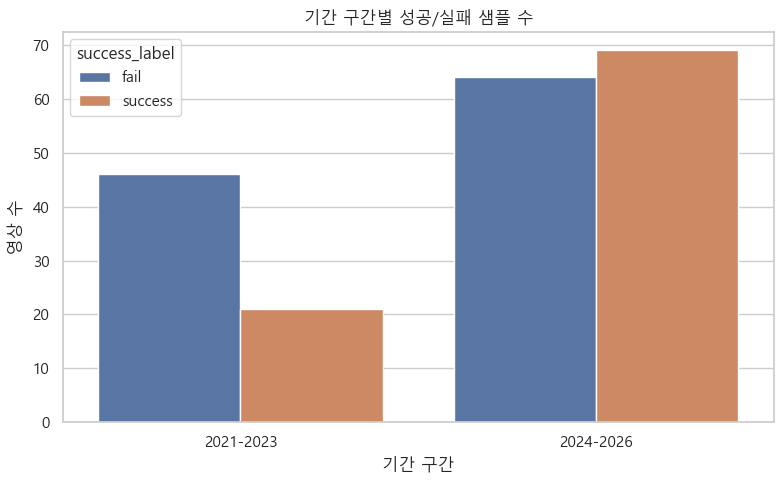

In [33]:
def make_period_group(year):
    if pd.isna(year):
        return "unknown"
    elif year <= 2023:
        return "2021-2023"
    else:
        return "2024-2026"

if "upload_year" in df.columns:
    df["period_group"] = df["upload_year"].apply(make_period_group)
    
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df,
        x="period_group",
        hue="success_label"
    )
    plt.title("기간 구간별 성공/실패 샘플 수")
    plt.xlabel("기간 구간")
    plt.ylabel("영상 수")
    plt.tight_layout()
    plt.show()

# 15. 대표 사례 확인

In [36]:
# 예시: FnB 성공 + 첫 3초 인물
display(
    df[
        (df["domain"] == "FnB") &
        (df["success_label"] == "success") &
        (df["first_3sec"] == "인물")
    ][["video_id", "채널명", "title", "first_3sec", "video_format", "reason"]]
    .head(3)
)

,video_id,채널명,title,first_3sec,video_format,reason
53,HlMzYdlsZuA,삼립,이장우 매력 폭발하는 味장센✨,인물,광고/CF,"전문적인 조명과 편집, 특수효과가 사용되었으며, 빵을 맛있게 먹는 인물의 반응을 중..."
54,eQmFyYH2n48,KFC Korea,[KFC] 최현석 X KFC 켄치짜🗽✨,인물,광고/CF,"전문적인 촬영과 편집, 빠른 전환으로 KFC 신제품을 광고하는 영상입니다. 인물이 ..."
60,xv_fRTHnA9w,BUDWEISER KOREA,휘인(Whee In) ‘파스텔(Pastel)’ ​​라이브 맛보기 | BEAT THE...,인물,이벤트/행사,전문적인 스튜디오 환경에서 촬영된 고품질 라이브 공연 영상입니다. 강렬한 빨간색 배...


In [37]:
# 예시: IT 성공 + 모션그래픽 핵심요소
display(
    df[
        (df["domain"] == "IT") &
        (df["success_label"] == "success") &
        (df["motion_graphic"] == "핵심요소")
    ][["video_id", "채널명", "title", "motion_graphic", "video_format", "reason"]]
    .head(3)
)

,video_id,채널명,title,motion_graphic,video_format,reason
160,805G5c85sbc,[CJ OliveNetworks] CJ올리브네트웍스,IT 기업의 현실,핵심요소,에피소드소개,"IT 기업 직원의 출근, 업무, 결제 상황을 기대와 현실로 나누어 보여주는 에피소드..."
162,DaoCjAz_KuQ,카카오모빌리티,판교 막내 직장인이 AI를 만났을 때,핵심요소,브이로그,"영상은 카카오 T 직원이 AI 영상을 제작하는 과정을 담은 브이로그 형식으로, 사무..."
163,_G0QeTabvBE,티머니,모바일티머니 고객이라면 유심교체 전 꼭 확인! #skt #usim #유심교체 #티머니,핵심요소,튜토리얼,"영상 전체가 모션 그래픽으로 구성되어 있으며, 선명한 색감과 빠른 편집 속도로 정보..."


In [39]:
# 예시: text_ratio 높은 성공 영상
display(
    df[
        df["success_label"] == "success"
    ][["video_id", "domain", "채널명", "title", "text_ratio", "first_3sec", "reason"]]
    .sort_values("text_ratio", ascending=False)
    .head(10)
)

,video_id,domain,채널명,title,text_ratio,first_3sec,reason
58,Ug_tE5yVllI,FnB,동원TV,"[뉴스룸] 동원산업, 연근해 어업조합과 연안 참다랑어 유통 체계 구축",1.00,텍스트,"기업의 새로운 유통 체계 구축을 알리는 홍보 영상으로, 전문적인 촬영과 편집, 모션..."
73,LyrdfeANw0U,FnB,Coca-Cola Korea,[#코카콜라] 짜릿한 게 필요해? 15s,1.00,인물,"전문적인 촬영 장비와 편집 기술이 사용되었으며, 다양한 조명과 배경이 혼합되어 사용..."
193,B0he9er5Naw,IT,ETEVERS GROUP 에티버스그룹,IT 회사 직원들은 AI 이거 씀 #ai #개발자 #IT회사,1.00,텍스트,IT 회사 직원들이 사용하는 AI 툴에 대한 인터뷰 형식의 숏츠 영상입니다. 깔끔한...
163,_G0QeTabvBE,IT,티머니,모바일티머니 고객이라면 유심교체 전 꼭 확인! #skt #usim #유심교체 #티머니,1.00,텍스트,"영상 전체가 모션 그래픽으로 구성되어 있으며, 선명한 색감과 빠른 편집 속도로 정보..."
90,fUqd9wsBg1w,FnB,더카페,카페운영 어렵지 않아요. 담당 DM 밀착 케어 시스템으로 쉽게 운영하세요! #카페창업,1.00,인물,"영상은 실내에서 진행된 인터뷰 형식으로, 인물이 질문에 답하는 동안 텍스트 자막과 ..."
194,PPOU-rfIgfY,IT,만나플러스,배송원 시간제보험 Q&A 안내,1.00,텍스트,영상은 전문적인 2D 애니메이션으로 제작된 Q&A 형식의 정보 전달 콘텐츠입니다. ...
82,ed6SKWMt86g,FnB,하이트진로음료,초콜릿 못 받아도 우울해하지 말기.. #shorts,1.00,텍스트,"그래픽 기반의 선택형 콘텐츠로, 깔끔한 디자인과 텍스트가 주를 이룹니다. 전반적으로..."
61,EiyqYdB6YmU,FnB,사조대림,술자리 이런 친구 꼭 있음! | 자취생존기 E.4 #shorts,0.95,텍스트,"실내 인공조명 환경에서 친구들과 술자리를 가지는 웹예능 형식의 영상으로, 따뜻한 색..."
55,jbx86fAAfBk,FnB,코레일유통TV,"KTX 개통 20주년 맞이, 한정판 KTX-산천 조립 블록 출시!!✨ #코레일유통 ...",0.95,제품,영상 전체가 고품질의 모션 그래픽으로 제작된 제품 광고입니다. 밝고 선명한 색감과 ...
56,wk6DRd6cdnU,FnB,그레인온,"[그레인온] 효소의 진화🚀 장까지 가는 진짜 효소, 캡슐레이션 등장!",0.95,텍스트,"영상 전반적으로 전문적인 촬영과 편집이 돋보이며, 인공 조명을 활용하여 따뜻한 색감..."


# 16. EDA 결과 저장

In [ ]:
# OUTPUT_DIR = Path("eda_outputs")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# numeric_diff_df.to_csv(
#     OUTPUT_DIR / "shorts_numeric_success_fail_diff.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# category_all = []

# for col, table in category_diff_dict.items():
#     temp = table.copy()
#     temp["feature"] = col
#     temp["category"] = temp[col]
#     category_all.append(
#         temp[["domain", "feature", "category", "success", "fail", "diff_success_minus_fail"]]
#     )

# category_diff_all = pd.concat(category_all, ignore_index=True)

# category_diff_all.to_csv(
#     OUTPUT_DIR / "shorts_category_success_fail_diff.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# color_summary.to_csv(
#     OUTPUT_DIR / "shorts_top_colors_summary.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("EDA 결과 저장 완료")